This notebook presents some of the figures generated for the analysis of sections with multiple measurements in time

In [176]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *
from main.heterogeneity_regression import fit_linear_regression
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

## Wat voorspellen we?

In [177]:
#load the data
db_name = 'database_all_v5.sqlite'
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data',db_name)))
df_final = load_and_merge_data(working_dir.parent.joinpath('data',db_name))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)

#rename section schoor-wierum_ to t_schoor_-_wierum_46,1 - 49,7
df_final.loc[df_final['dike_name']=='schoor-wierum_','dike_name'] = 't_schoor_-_wierum_46,1 - 49,7'
#also in data_per_dike_project
data_per_dike_project.loc[data_per_dike_project['dike_name']=='schoor-wierum_','dike_name'] = 't_schoor_-_wierum_46,1 - 49,7'




In [178]:
unique_sections = data_per_dike_project.dike_name.unique()
#find pattern: name_with_underscores_number - number
import re
pattern = re.compile(r'^(.*)_(\d+,\d+)\s*-\s*(\d+,\d+)$')
#store in dict with name, start, end
section_bounds = {}
for section in unique_sections:
    match = pattern.match(section)
    if match:
        name = match.group(1)
        start = float(match.group(2).replace(',', '.'))
        end = float(match.group(3).replace(',', '.'))
        section_bounds[section] = (start, end)

#get all start and end values in a list, and also the keys = []
sections_lengths = []
for key, (start, end) in section_bounds.items():
    sections_lengths.append((key, np.abs(end - start)))

#make dataframe from sections_lengths
sections_lengths_df = pd.DataFrame(sections_lengths, columns=['dike_name', 'length'])

In [179]:
#merge to data_per_dike_project
data_per_dike_project = data_per_dike_project.merge(sections_lengths_df, on='dike_name', how='left')



Text(0, 0.5, 'Standaardafwijking buigtreksterkte (MPa)')

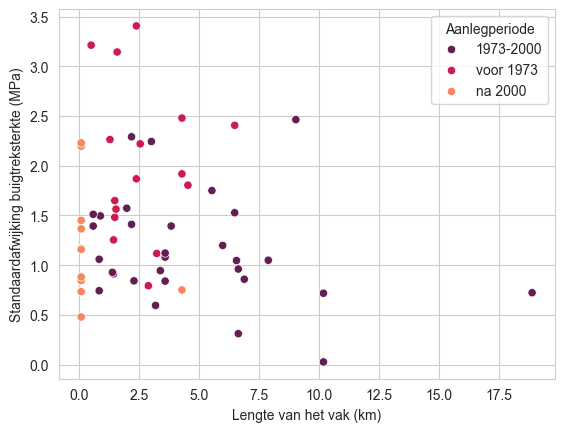

In [180]:
#scatterplot of length vs sig_b_cov, colored by heterogeneity_category
sns.scatterplot(data=data_per_dike_project.rename(columns={'construction_year_category': 'Aanlegperiode'}), x='length', y='sig_b_std', hue='Aanlegperiode',palette='rocket')
plt.xlabel('Lengte van het vak (km)')
plt.ylabel('Standaardafwijking buigtreksterkte (MPa)')

In [181]:
#load the matrix of dike names and whether they are connected or not (1 means connected)
dike_connections = pd.read_excel(working_dir.parent.joinpath('data','dike_connections.xlsx'))
dike_connections.set_index('dike_name', inplace=True)
#make a list of dike names and the number of corresponding dike_names by summing by row
dike_connections['num_connections'] = dike_connections.sum(axis=1)
#drop schoor-wierum_
dike_connections = dike_connections.drop('schoor-wierum_', errors='ignore')


## Original analysis

Plot for each section the time series as boxplots

In [182]:
#count in df_final the number of dike_project_ids for the same dike_name
multiple_projects = df_final.groupby('dike_name')['project_dike_id'].nunique()
#show the number of dike_names with more than 1 dike_project_id
multiple_projects = multiple_projects[multiple_projects > 1]
multiple_projects

#count number of boreholes for these dikenames
count_boreholes = df_final[df_final['dike_name'].isin(multiple_projects.index)].groupby('dike_name')['borehole_id'].nunique()
count_boreholes


dike_name
emmapolder_47,5 - 57                                       23
lauwersmeerdijk_friesland_57,5 - 61,8                      18
noorderhavendam_0 - 1,206                                  20
proefvakken_pov-wadden_-_vak_1_(harlingen)_-               16
proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3    16
proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3    16
proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5        15
proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6-17,7        16
proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8-17,9        16
t_schoor_-_wierum_46,1 - 49,7                              24
van_pallandtdijk_13,45 - 15,85                             18
Name: borehole_id, dtype: int64

In [183]:
dike_connections[['num_connections']].sort_values('num_connections', ascending=False).head(25)

#count total number of boreholes in sections with num_connections > 1
total_boreholes = df_final[df_final['dike_name'].isin(dike_connections[dike_connections['num_connections'] > 1].index)].groupby('dike_name')['borehole_id'].nunique()
print(total_boreholes.sum())
#count total number of boreholes in sections with num_connections >1 and/or multiple projects
total_boreholes_multi = df_final[df_final['dike_name'].isin(dike_connections[dike_connections['num_connections'] > 1].index) | df_final['dike_name'].isin(multiple_projects.index)].groupby('dike_name')['borehole_id'].nunique()
total_boreholes_multi.sum()




196


np.int64(352)

In [184]:
import numpy as np
dike_connections[['num_connections']].sort_values('num_connections', ascending=False).head(10)

#for each dike_name in dike_connections where num_connections > 1: select the data from df_final where dike_name is that dike_name or any of the connected dike_names
#make a list of the index such that we can pop the sections already plotted
plotted_for = [] 
dike_list = dike_connections.index.tolist()
#also make a list of dike_names where there are multiple project_id's for the same dike_name
multiple_projects = dikes_and_projects.groupby('dike_name')['project_id'].nunique()
multiple_projects = multiple_projects[multiple_projects > 1].index.tolist()
results_dir.joinpath(f'timeseries_per_section_HR').mkdir(parents=True, exist_ok=True)
for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        fig, ax = plt.subplots(figsize=(6,5),ncols=2)
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        sns.boxplot(data=dike_data, x='age_at_investigation', y='HR', ax=ax[0], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='HR', hue='sig_b', palette='YlGnBu',hue_norm=(2, 13), ax=ax[0],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='HR', ci=None, scatter=False, ax=ax[0], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   
        norm = plt.Normalize(2, 13)
        sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=norm)
        sm.set_array([])
        ax[0].set_title(f'HR in tijd')
        ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
        ax[0].set_ylabel('Holle ruimte (%)')

        # ax[0].set_xlim(-1.2, 6.2)
        ax[0].set_ylim(0, 15)
        ax[0].get_legend().remove()
        ax[0].figure.colorbar(sm, ax=ax[0],label='Buigtreksterkte (MPa)', fraction=0.046, pad=0.04)
        #fix x_ticks to be integers at the right positions
        ax[0].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[0].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])        
        #plot 2: boxplot van sig_b met punten gekleurd als HR
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax[1], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='sig_b', hue='HR', palette='YlOrRd',hue_norm=(1, 10), ax=ax[1],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax[1], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   
        norm = plt.Normalize(1, 10)
        sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
        sm.set_array([])
        
        ax[1].set_title(f'sig_b in tijd')
        ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
        ax[1].set_ylabel('Buigtreksterkte (MPa)')
        # ax[1].set_xlim(-1.2, 6.2)
        ax[1].set_ylim(0, 13)
        ax[1].get_legend().remove()
        ax[1].figure.colorbar(sm, ax=ax[1],label='Holle ruimte (%)', fraction=0.046, pad=0.04)
        # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax[1].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[1].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        plt.suptitle(f'{dike}')
        #add horizontal spacing
        plt.subplots_adjust(wspace=1.0)
        plt.savefig(results_dir.joinpath(f'timeseries_per_section/{dike}_and_connected_dikes.png'), bbox_inches='tight')
        plt.close()

        plotted_for.append((dike, len(connected_dikes)))
        #pop the dike and connected dikes from the dike_list
        for cd in connected_dikes:
            if cd in dike_list:
                dike_list.remove(cd)

#print table with name and number of connected dikes

pd.DataFrame(plotted_for, columns=['dike_name', 'num_connected_dikes']).to_csv(results_dir.joinpath('timeseries_per_section','plotted_dike_sections.csv'), index=False)
plotted_for

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\738641768.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\738641768.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\i

[('amsteldiepdijk_14,8-12,5', 2),
 ('balgzanddijk_4,6 - 14,8', 2),
 ('eemshaven_(dijkvak_48)_0,65 - 2,1', 2),
 ('eemshaven_(dijkvak_49)_38,5-41,75', 2),
 ('emmapolder_47,5 - 57', 2),
 ('helderse_zeewering_-_kaaphoofd_', 2),
 ('langgrousterwei_55,3 - 57,5', 3),
 ('lauwersmeerdijk_friesland_55,3 - 61,8', 2),
 ('martina_corneliadijk_15,85 - 17,45', 2),
 ('noorderhavendam_0 - 1,206', 2),
 ('proefvakken_pov-wadden_-_vak_1_(harlingen)_-', 2),
 ('proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3', 2),
 ('proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6-17,7', 2),
 ('t_schoor_-_veerdam_holwerd_40,7 - 49,75', 6),
 ('zuiderdiepdijk_4,3 - 6,86', 2)]

POV Wadden

In [185]:
#boxplots van sig_b met punten gekleurd als HR
dike_list = [ 'proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',
 'proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6-17,7',
 'proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8-17,9',]

#for each dike_name in dike_connections where num_connections > 1: select the data from df_final where dike_name is that dike_name or any of the connected dike_names
#make a list of the index such that we can pop the sections already plotted
plotted_for = [] 

results_dir.joinpath(f'timeseries_POVWadden').mkdir(parents=True, exist_ok=True)
for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        dike_data = df_final[df_final['dike_name'].isin([dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        fig, ax = plt.subplots(figsize=(6,5),ncols=2)
        
        #plot 1: histogram van HR per investigation year
        # sns.histplot(data=dike_data, x='HR', hue='investigation_year', binrange= (1, 10), binwidth=0.5, stat='density', common_norm=True, palette='tab10', ax=ax[0])
        # ax[0].set_title(f'Verdeling HR')
        sns.boxplot(data=dike_data, x='age_at_investigation', y='HR', ax=ax[0], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='HR', hue='sig_b', palette='YlGnBu',hue_norm=(2, 13), ax=ax[0],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='HR', ci=None, scatter=False, ax=ax[0], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   
        norm = plt.Normalize(2, 13)
        sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=norm)
        sm.set_array([])
        ax[0].set_title(f'HR in tijd')
        ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
        ax[0].set_ylabel('Holle ruimte (%)')

        ax[0].set_xlim(-1.2, 6.2)
        ax[0].set_ylim(1, 10)
        ax[0].get_legend().remove()
        ax[0].figure.colorbar(sm, ax=ax[0],label='Buigtreksterkte (MPa)', fraction=0.046, pad=0.04)
        #fix x_ticks to be integers at the right positions
        ax[0].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[0].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])        
        #plot 2: boxplot van sig_b met punten gekleurd als HR
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax[1], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='sig_b', hue='HR', palette='YlOrRd',hue_norm=(1, 10), ax=ax[1],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax[1], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   
        norm = plt.Normalize(1, 10)
        sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
        sm.set_array([])
        
        ax[1].set_title(f'sig_b in tijd')
        ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
        ax[1].set_ylabel('Buigtreksterkte (MPa)')
        ax[1].set_xlim(-1.2, 6.2)
        ax[1].set_ylim(2, 13)
        ax[1].get_legend().remove()
        ax[1].figure.colorbar(sm, ax=ax[1],label='Holle ruimte (%)', fraction=0.046, pad=0.04)
        # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax[1].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[1].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        plt.suptitle(f'{dike}')
        #add horizontal spacing
        plt.subplots_adjust(wspace=1.0)
        plt.savefig(results_dir.joinpath(f'timeseries_POVWadden/{dike}.png'), bbox_inches='tight')
        plt.close()



C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\3756094734.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\3756094734.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\3264064729.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\3264064729.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
C:\Users\klerk_wj\AppData\Local\Temp

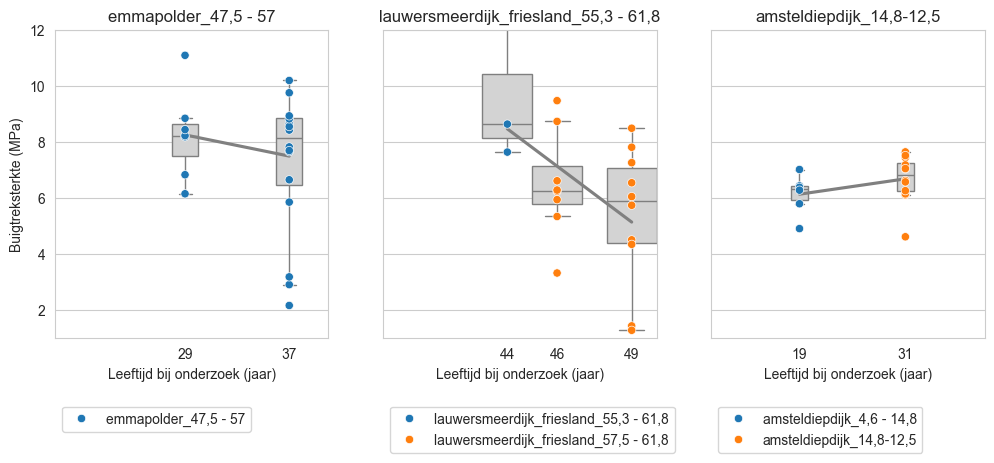

In [186]:
#plot voor
subset = [ 'emmapolder_47,5 - 57',
 'lauwersmeerdijk_friesland_55,3 - 61,8',
 'amsteldiepdijk_14,8-12,5',]
fig, ax = plt.subplots(figsize=(12,4), ncols=3)
for count, dike in enumerate(subset):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        #make a scatterplot of age_at_investigation vs sig_b, colored by dike_name
        #add age_since_first_investigation column
        dike_data['age_since_first_investigation'] = dike_data['age_at_investigation'] - dike_data['age_at_investigation'].min()
        #add boxplot for each of the unique values of age_at_investigation, make sure that boxplots align on x-axis
        sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax[count], color='lightgray', fliersize=1, width=2, positions=sorted(dike_data['age_at_investigation'].unique()),zorder=1)
        sns.scatterplot(data=dike_data, x='age_at_investigation', y='sig_b', hue='dike_name', palette='tab10',ax=ax[count],zorder=1000)
        sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax[count], color='gray')
        # sns.boxplot(data=dike_data, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', fliersize=0, width=0.5)   
        
        ax[count].set_title(f'{dike}')
        ax[count].set_xlabel('Leeftijd bij onderzoek (jaar)')
        # ax.set_ylabel('Buigtreksterkte (MPa)')`
        if count == 0:
            ax[count].set_ylabel('Buigtreksterkte (MPa)')
        else:
            ax[count].set_ylabel('')
            ax[count].set_yticklabels([])
        ax[count].set_xlim(np.floor(dike_data.age_at_investigation.min()/10)*10, np.ceil(dike_data.age_at_investigation.max()/10)*10)
        ax[count].legend(bbox_to_anchor=(0, -.20), loc='upper left')
        #fix x_ticks to be integers at the right positions
        ax[count].set_xticks(sorted(dike_data['age_at_investigation'].unique()))
        ax[count].set_xticklabels([str(int(x)) for x in sorted(dike_data['age_at_investigation'].unique())])
        ax[count].set_ylim(1, 12)
        ax[count].set_xlim(left =ax[count].get_xlim()[0]-1, right=ax[count].get_xlim()[1])
        # plt.savefig(results_dir.joinpath(f'timeseries_per_section_HR/{dike}_and_connected_dikes.png'), bbox_inches='tight')
        # plt.close()


## Analysis for chapter 4
Here we outline the analysis for chapter 4

In [187]:
#first we enrich the data by adding main_dike_name column
dike_list = dike_connections.index.tolist()
multiple_projects = dikes_and_projects.groupby('dike_name')['project_id'].nunique()
multiple_projects = multiple_projects[multiple_projects > 1].index.tolist()
dike_datasets = []
for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
    # if (dike in multiple_projects):
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]        
        dike_data.loc[:, 'main_dike_name'] = dike
        dike_datasets.append(dike_data)
#concat all dike_datasets
df_dikes_enriched = pd.concat(dike_datasets, ignore_index=True)
#save to csv
df_dikes_enriched.to_csv(results_dir.joinpath('dike_data_enriched.csv'), index=False)
df_dikes_enriched.borehole_id.nunique()

df_final = df_final.loc[df_final.age_at_investigation <= 50]

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\396188404.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data.loc[:, 'main_dike_name'] = dike
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\396188404.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data.loc[:, 'main_dike_name'] = dike
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\396188404.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [188]:
#loop through df_dikes_enriched for each main_dike_name and then identify if there is another main_dike_name with exactly the same borehole_ids
main_dike_names = df_dikes_enriched['main_dike_name'].unique()
duplicate_main_dike_names = []
for i, main_dike_1 in enumerate(main_dike_names):
    boreholes_1 = set(df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike_1]['borehole_id'].unique())
    for main_dike_2 in main_dike_names[i+1:]:
        boreholes_2 = set(df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike_2]['borehole_id'].unique())
        if boreholes_1 == boreholes_2:
            duplicate_main_dike_names.append((main_dike_1, main_dike_2))
duplicate_main_dike_names

#filter df_dikes_enriched and throw out all rows where main_dike_name is in duplicate_main_dike_names[1]
df_dikes_enriched = df_dikes_enriched[~df_dikes_enriched['main_dike_name'].isin([dup[1] for dup in duplicate_main_dike_names])]
#count number of unique borehole_ids again

#make a list again of all main_dike_names
main_dike_names = df_dikes_enriched['main_dike_name'].unique()




In [189]:
# filter out anomalies: 
excluded_main_sections = ['proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',  #inconsistente HR
'proefvakken_pov-wadden_-_vak_1_(harlingen)_-', #inconsistente HR
'martina_corneliadijk_15,85 - 17,45', # zeer hoge HR waarden + beide metingen ouder dan 50 jaar
'noorderhavendam_0 - 1,206', #tijdsinterval van 2 jaar
'van_pallandtdijk_13,45 - 15,85', #beide metingen ouder dan 50 jaar
'balgzanddijk_12,5-4,6', # maar 2 boorkernen op eerste tijdstip
'wierum-holwerd,vak1_40,7 - 42,9', # zeer korte tijdsinterval
'wierum-holwerd,vak2_42,9 - 46,1', # beide zeer korte tijdsinterval
'lauwersmeerdijk_friesland_55,3 - 61,8',] # tijdsinterval tussen metingen is zeer kort, en leidt tot extreem steile afname door 3 zeer gunstige boorkernen op eerste tijdstip.
df_dikes_enriched = df_dikes_enriched[~df_dikes_enriched['main_dike_name'].isin(excluded_main_sections)]

# # for lauwersmeerdijk: move first investigation 2 years ahead to prevent inconsistency in data
# df_dikes_enriched.loc[(df_dikes_enriched['main_dike_name']=='lauwersmeerdijk_friesland_55,3 - 61,8') & (df_dikes_enriched['investigation_year'] == 2009), 'age_at_investigation'] =46
# df_dikes_enriched.loc[(df_dikes_enriched['main_dike_name']=='lauwersmeerdijk_friesland_55,3 - 61,8') & (df_dikes_enriched['investigation_year'] == 2009), 'investigation_year'] =2011

#add the age_since_first_investigation column to df_dikes_enriched
df_dikes_enriched['time_since_first_investigation'] = df_dikes_enriched.groupby('main_dike_name')['age_at_investigation'].transform(lambda x: x - x.min())

#determine the normalized sig_b for each main_dike_name based on the mean sig_b at first investigation
df_dikes_enriched['sig_b_normalized'] = df_dikes_enriched.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['age_at_investigation'] == x['age_at_investigation'].min(), 'sig_b'].mean()).reset_index(level=0, drop=True)

#shorten the dike names by omitting _(westhoek)_ if it occurs
df_dikes_enriched['main_dike_name'] = df_dikes_enriched['main_dike_name'].str.replace('_(westhoek)_', '_', regex=False)

main_dike_names = df_dikes_enriched['main_dike_name'].unique()

df_dikes_enriched.shape

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\584761376.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dikes_enriched['sig_b_normalized'] = df_dikes_enriched.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['age_at_investigation'] == x['age_at_investigation'].min(), 'sig_b'].mean()).reset_index(level=0, drop=True)


(270, 47)

In [190]:
df_dikes_enriched.borehole_id.nunique()

234

## Combined regression for all sections

Text(0.5, 1.0, 'Buigtreksterkte in tijd voor geselecteerde dijkvakken')

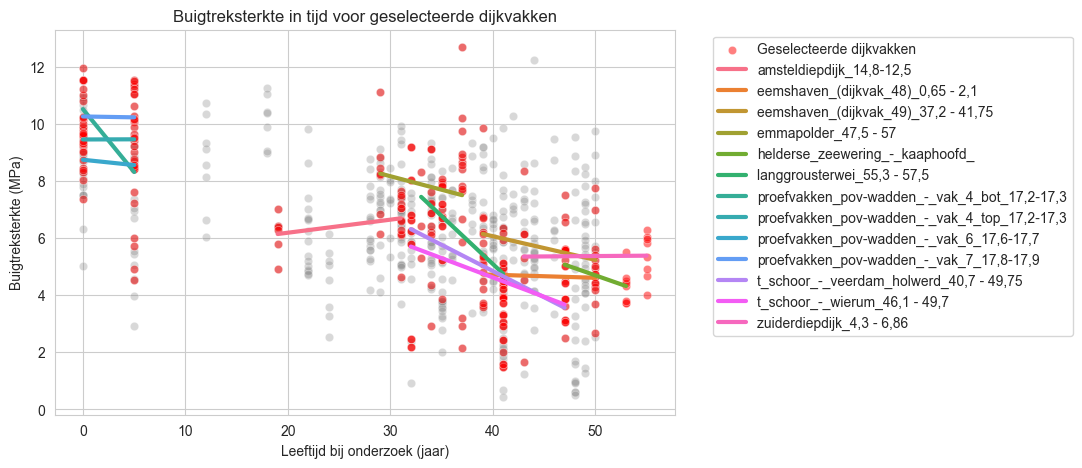

In [191]:

df_dikes_enriched['target'] = df_dikes_enriched['sig_b']
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b',color='gray', alpha=0.3, ax=ax)
sns.scatterplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#for each main_dike_name, plot a line connecting the mean of the different investigation years
colors = sns.color_palette('husl', n_colors=len(df_dikes_enriched['main_dike_name'].unique()))
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax, color=colors[i], label = main_dike, line_kws={'lw':3})

ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')
plt.title('Buigtreksterkte in tijd voor geselecteerde dijkvakken')
# sns.regplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b', ci=None, scatter=True, color='gray')

# result = fit_linear_regression(df_dikes_enriched)
# result

## Absolute voorspelling

Text(0.5, 1.0, 'Buigtreksterkte in tijd voor geselecteerde dijkvakken')

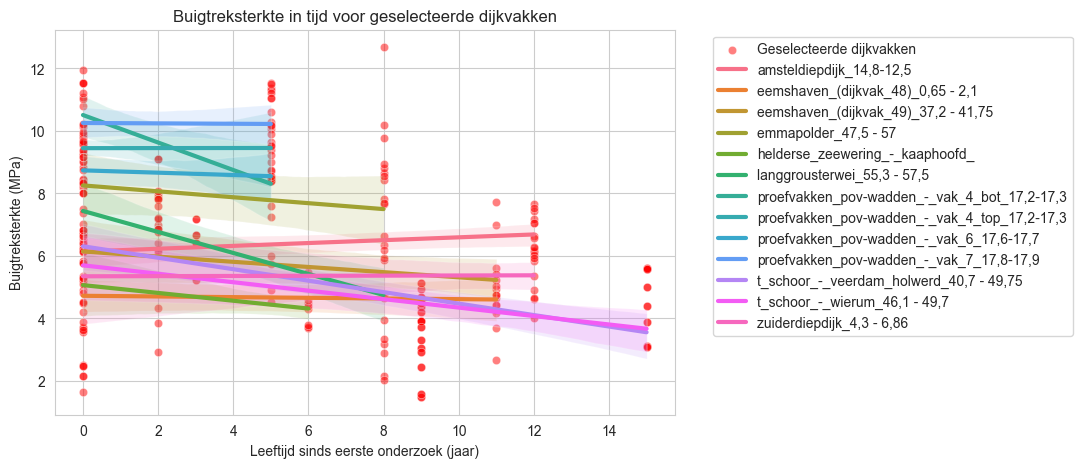

In [192]:

df_dikes_enriched['target'] = df_dikes_enriched['sig_b']
fig, ax = plt.subplots(figsize=(8,5))
# sns.scatterplot(data=df_final, x='time_since_first_investigation', y='sig_b',color='gray', alpha=0.3, ax=ax)
sns.scatterplot(data=df_dikes_enriched, x='time_since_first_investigation', y='sig_b', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#for each main_dike_name, plot a line connecting the mean of the different investigation years
colors = sns.color_palette('husl', n_colors=len(df_dikes_enriched['main_dike_name'].unique()))
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    sns.regplot(data=dike_data, x='time_since_first_investigation', y='sig_b', ci=90, scatter=False, ax=ax, color=colors[i], label = main_dike, line_kws={'lw':3})
    #also do based on the mean sig_b per time_since_first_investigation
    mean_dike_data = dike_data.groupby('time_since_first_investigation')['sig_b'].mean().reset_index()
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
ax.set_xlabel('Leeftijd sinds eerste onderzoek (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_title('Buigtreksterkte in tijd voor geselecteerde dijkvakken')


Text(0.5, 1.0, 'Buigtreksterkte in tijd voor geselecteerde dijkvakken')

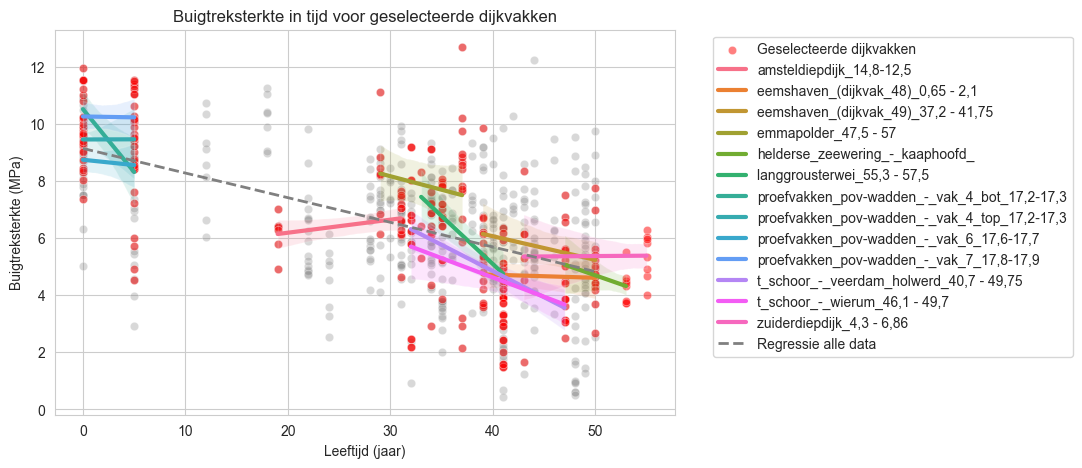

In [193]:

df_dikes_enriched['target'] = df_dikes_enriched['sig_b']
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b',color='gray', alpha=0.3, ax=ax)
sns.scatterplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#for each main_dike_name, plot a line connecting the mean of the different investigation years
colors = sns.color_palette('husl', n_colors=len(df_dikes_enriched['main_dike_name'].unique()))
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', ci=90, scatter=False, ax=ax, color=colors[i], label = main_dike, line_kws={'lw':3})
    #also do based on the mean sig_b per time_since_first_investigation
sns.regplot(data=df_final, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax, color='gray', line_kws={'lw':2, 'ls':'--'},label='Regressie alle data')
# sns.regplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b', ci=None, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'})
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
ax.set_xlabel('Leeftijd (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_title('Buigtreksterkte in tijd voor geselecteerde dijkvakken')


## Relatieve afname

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\444735629.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dikes_mean['sig_b_relative'] = df_dikes_mean.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['time_since_first_investigation'] == x['time_since_first_investigation'].min(), 'sig_b'].values[0]).reset_index(level=0, drop=True)


<Axes: xlabel='time_since_first_investigation', ylabel='sig_b_relative'>

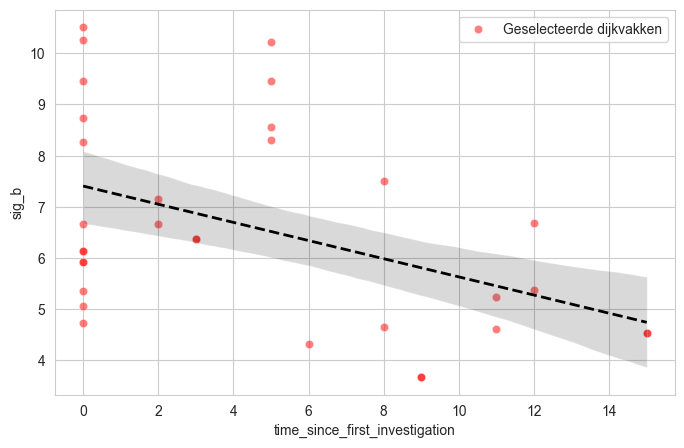

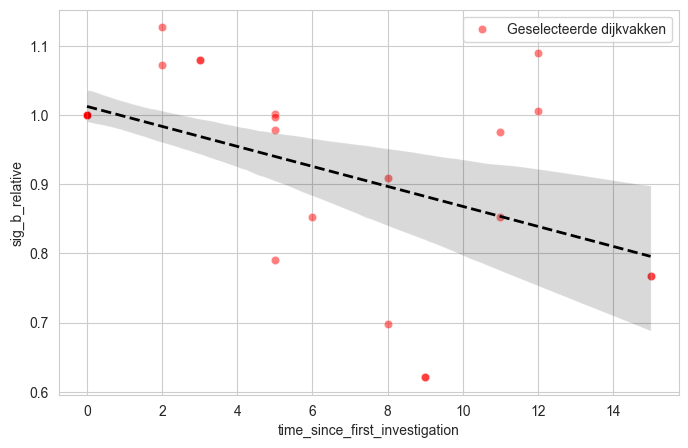

In [194]:
#make dataframe from df_dikes_enriched with only main_dike_name, time_since_first_investigation, sig_b, where sig_b is the mean sig_b for each main_dike_name and time_since_first_investigation
df_dikes_mean = df_dikes_enriched.groupby(['main_dike_name', 'time_since_first_investigation']).agg({'sig_b': 'mean'}).reset_index()
#add a relative sig_b relative to the first time_since_first_investigation per main_dike_name
df_dikes_mean['sig_b_relative'] = df_dikes_mean.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['time_since_first_investigation'] == x['time_since_first_investigation'].min(), 'sig_b'].values[0]).reset_index(level=0, drop=True)

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_dikes_mean, x='time_since_first_investigation', y='sig_b', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#do a regression on all the mean data
sns.regplot(data=df_dikes_mean, x='time_since_first_investigation', y='sig_b', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_dikes_mean, x='time_since_first_investigation', y='sig_b_relative', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#do a regression on all the mean data
sns.regplot(data=df_dikes_mean, x='time_since_first_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\641817014.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')


Text(0, 0.5, 'Genormaliseerde buigtreksterkte $\\sigma_b/\\sigma_0$')

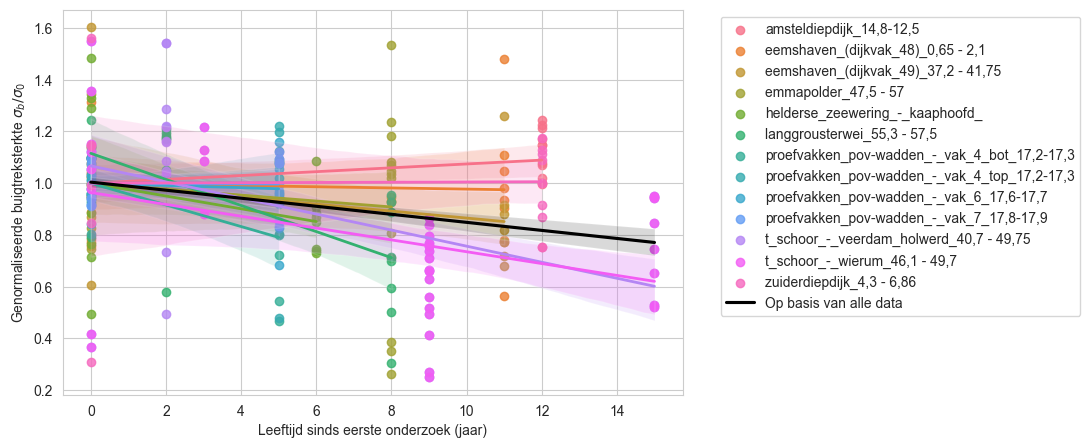

In [195]:
fig, ax = plt.subplots(figsize=(8,5))
# sns.scatterplot(data=df_dikes_enriched.loc[df_dikes_enriched['time_since_first_investigation'] > 0], x='time_since_first_investigation', y='sig_b_normalized', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')

#add for individual sections
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    #get log_normalized sig_b
    # dike_data['sig_b_normalized'] = np.log(dike_data['sig_b_normalized'])
    # dike_data['target'] = dike_data['sig_b_normalized']
    # dike_data.loc[dike_data.time_since_first_investigation == 0, 'sig_b_normalized'] = 1.0
    # #add 100 points at time_since_first_investigation = 0 with sig_b_normalized = 1.0
    # dike_data = pd.concat([dike_data, pd.DataFrame({'time_since_first_investigation': [0]*100, 'sig_b_normalized': [1.0]*100})], ignore_index=True)
    sns.regplot(data=dike_data, x='time_since_first_investigation', y='sig_b_normalized', ci=90, scatter=True, ax=ax, color=colors[i], label = main_dike, line_kws={'lw':2})
    # dike_result = fit_linear_regression(dike_data, use_HR_as_regressor=False)
    # mean_dike, ci_lower_dike, ci_upper_dike = get_data_from_regression(dike_result, x_grid)
    # ax.plot(x_grid,mean_dike, color=colors[i], label = main_dike)
    # ax.fill_between(x_grid, ci_lower_dike, ci_upper_dike, color=colors[i], alpha=0.2)

sns.regplot(data=pd.concat([df_dikes_enriched[['time_since_first_investigation', 'sig_b_normalized']], pd.DataFrame({'time_since_first_investigation': [0]*100, 'sig_b_normalized': [1.0]*100})], ignore_index=True), x='time_since_first_investigation', y='sig_b_normalized', ci=90,scatter=False, ax=ax, color='black',label='Op basis van alle data')
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
ax.set_xlabel('Leeftijd sinds eerste onderzoek (jaar)')
ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')



Regression to derive the KDE of the slope

In [196]:
slope_intercept = {}
for count, dike in enumerate(main_dike_names):
    #filter the df_final for the dike and connected dikes
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == dike]
    #select only the relevant columns
    dike_data = dike_data[['time_since_first_investigation', 'sig_b_normalized']]
    #for all rows where time_since_first_investigation is 0, set sig_b_normalized to 1.0
    # dike_data.loc[dike_data.time_since_first_investigation == 0, 'sig_b_normalized'] = 1.0
    #add 100 points at time_since_first_investigation = 0 with sig_b_normalized = 1.0
    # dike_data = pd.concat([dike_data, pd.DataFrame({'time_since_first_investigation': [0]*100, 'sig_b_normalized': [1.0]*100})], ignore_index=True)
    dike_data["target"] = dike_data["sig_b_normalized"]

    #temporary rename time_since_first_investigation to age_at_investigation to reuse function
    dike_data = dike_data.rename(columns={'time_since_first_investigation': 'age_at_investigation'})
        
    #do a regression with sklearn to get slope and intercept of sig_b vs age_at_investigation
    results = fit_linear_regression(dike_data, use_HR_as_regressor=False)
    slope_intercept[dike] = {'slope': results['summary_dict']['age_at_investigation']['Coef.'],
                                'slope_std': results['summary_dict']['age_at_investigation']['Std.Err.'],
                                'slope_ci_lo':  results['summary_dict']['age_at_investigation']['[0.025'], 
                                'slope_ci_hi': results['summary_dict']['age_at_investigation']['0.975]'],
                                'intercept': results['summary_dict']['const']['Coef.'],
                                'intercept_ci_lo': results['summary_dict']['const']['[0.025'],
                                'intercept_ci_hi': results['summary_dict']['const']['0.975]'],
                                't0': dike_data['age_at_investigation'].min(),
                                'tmax': dike_data['age_at_investigation'].max(),}

#regressions for each
slope_intercept_df = pd.DataFrame.from_dict(slope_intercept, orient='index')
#drop nans
slope_intercept_df = slope_intercept_df.dropna()

slope_intercept_df

#fit regression on full set
df_dikes_enriched["target"] = df_dikes_enriched["sig_b_normalized"]
full_data_results = fit_linear_regression(df_dikes_enriched, use_HR_as_regressor=False)
full_data_slope = full_data_results['summary_dict']['age_at_investigation']
full_data_slope


{'Coef.': -0.0026074986938540343,
 'Std.Err.': 0.0009159797753872115,
 't': -2.8466771471583727,
 'P>|t|': 0.004759501417340723,
 '[0.025': -0.004410930213336328,
 '0.975]': -0.0008040671743717409}

Mediaan afname geselecteerde dijkvakken: -1.25% per jaar
Gewogen gemiddelde afname geselecteerde dijkvakken: -0.96% per jaar
90% betrouwbaarheidsinterval: -5.57% - 1.53% per jaar


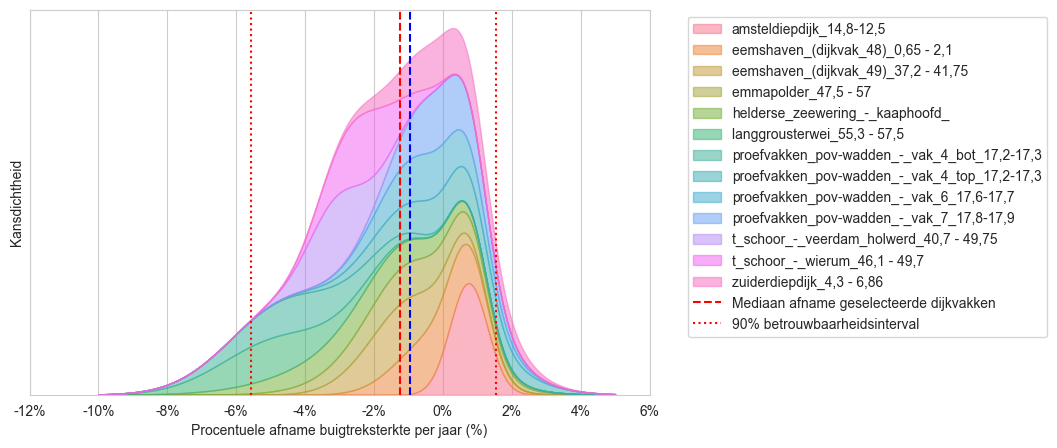

In [197]:
from scipy.stats import norm
#plot slope_intercept_df, make a kde plot of the slope and slope std from slope_intercept_df for each section
fig, ax = plt.subplots(figsize=(8,5))
x_range = np.linspace(-0.10, 0.05, 1000)
y_level = np.zeros(len(x_range))
for count, (i, row) in enumerate(slope_intercept_df.iterrows()):
    mean = row['slope']
    std = row['slope_std']
    kde = norm.pdf(x_range, mean, std)
    #additive plot with fill between
    ax.fill_between(x_range, y_level, y_level + kde, alpha=0.5,label = i, color=colors[count])
    y_level += kde

#get xticks and translate to percentage per year
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f'{x*100:.0f}%' for x in xticks])
ax.set_xlabel('Procentuele afname buigtreksterkte per jaar (%)')
ax.set_ylabel('Kansdichtheid')
ax.set_yticks([])
# ax.axvline(full_data_slope['Coef.'], color='black', linestyle='--', label='Gemiddelde afname alle dijkvakken')
ax.set_ylim(bottom=0)

#get cdf = 0.5 from y_level and plot as line
cumulative = np.cumsum(y_level)
cumulative = cumulative / cumulative[-1]
median_index = np.where(cumulative >= 0.5)[0][0]
lower_ci_05 = np.where(cumulative >= 0.05)[0][0]
upper_ci_95 = np.where(cumulative >= 0.95)[0][0]
median_slope = x_range[median_index]
ax.axvline(median_slope, color='red', linestyle='--', label='Mediaan afname geselecteerde dijkvakken')
ax.axvline(x_range[lower_ci_05], color='red', linestyle=':', label='90% betrouwbaarheidsinterval')
ax.axvline(x_range[upper_ci_95], color='red', linestyle=':')
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
#get mean
mean_slope = np.sum(slope_intercept_df['slope'] / slope_intercept_df['slope_std']**2) / np.sum(1 / slope_intercept_df['slope_std']**2)
ax.axvline(mean_slope, color='blue', linestyle='--', label='Gewogen gemiddelde afname geselecteerde dijkvakken')
print(f'Mediaan afname geselecteerde dijkvakken: {median_slope*100:.2f}% per jaar')
print(f'Gewogen gemiddelde afname geselecteerde dijkvakken: {mean_slope*100:.2f}% per jaar')
print(f'90% betrouwbaarheidsinterval: {x_range[lower_ci_05]*100:.2f}% - {x_range[upper_ci_95]*100:.2f}% per jaar')

In [198]:
df_dikes_mean.loc[df_dikes_mean['age_at_investigation'] == 0]

KeyError: 'age_at_investigation'

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\2355436709.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\2355436709.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dikes_mean['sig_b_relative'] = df_dikes_mean.groupby('main_dike_name').apply(lambda x: x['sig_b'] / mean_at_zero).reset_index(level=0, drop=True)


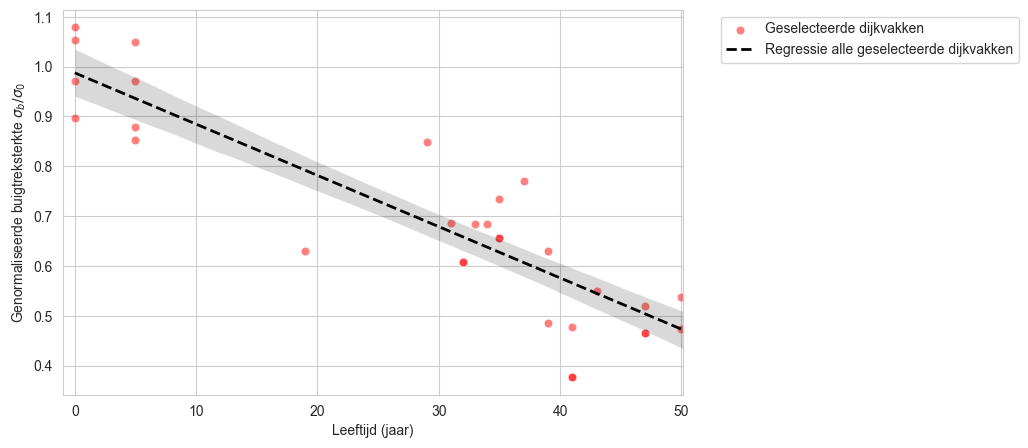

In [ ]:
# relative plot for the means. But dependent on the mean at t=0. Only df_dikes_mean
#make new df_dikes_mean with only main_dike_name, age_at_investigation, sig_b where sig_b is the mean sig_b for each main_dike_name and age_at_investigation
df_dikes_mean = df_dikes_enriched.groupby(['main_dike_name', 'age_at_investigation']).agg({'sig_b': 'mean'}).reset_index()
#make all sig_b relative to age_at_investigation == 0
#mean at age_at_investigation = 0
mean_at_zero = df_dikes_mean.loc[df_dikes_mean['age_at_investigation'] == 0, 'sig_b'].mean()
df_dikes_mean['sig_b_relative'] = df_dikes_mean.groupby('main_dike_name').apply(lambda x: x['sig_b'] / mean_at_zero).reset_index(level=0, drop=True)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_dikes_mean, x='age_at_investigation', y='sig_b_relative', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#do a regression on all the mean data
sns.regplot(data=df_dikes_mean, x='age_at_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')
# sns.regplot(data=df_dikes_mean.loc[df_dikes_mean.age_at_investigation > 6], x='age_at_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')
ax.set_xlabel('Leeftijd (jaar)')
ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')
ax.set_xlim(left= -1, right=50.1)
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\2759765484.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_20452\2759765484.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dikes_mean_all['sig_b_relative'] = df_dikes_mean_all.groupby('project_dike_id').apply(lambda x: x['sig_b'] / mean_at_zero).reset_index(level=0, drop=True)


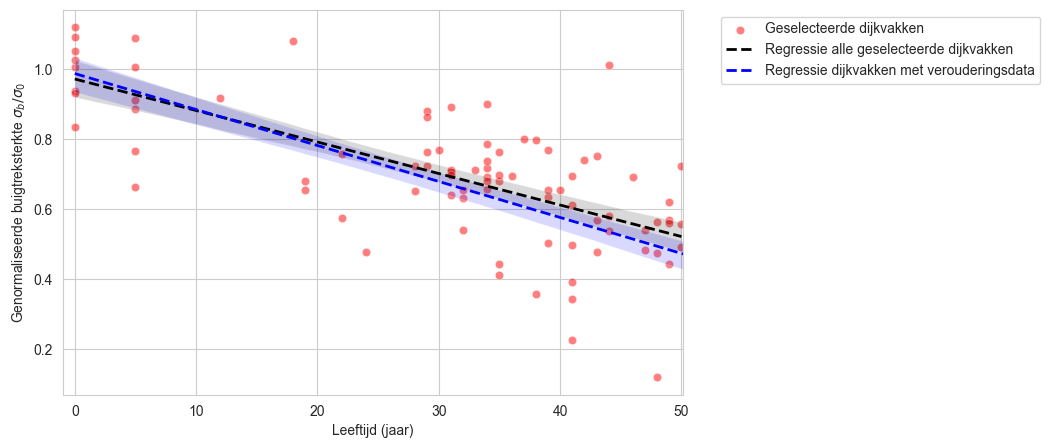

In [ ]:
# relative plot for the means. But dependent on the mean at t=0. Only df_dikes_mean
#make new df_dikes_mean with only main_dike_name, age_at_investigation, sig_b where sig_b is the mean sig_b for each main_dike_name and age_at_investigation
df_dikes_mean_all = df_final.groupby(['project_dike_id', 'age_at_investigation']).agg({'sig_b': 'mean'}).reset_index()
#make all sig_b relative to age_at_investigation == 0
#mean at age_at_investigation = 0
mean_at_zero = df_dikes_mean_all.loc[df_dikes_mean_all['age_at_investigation'] == 0, 'sig_b'].mean()
df_dikes_mean_all['sig_b_relative'] = df_dikes_mean_all.groupby('project_dike_id').apply(lambda x: x['sig_b'] / mean_at_zero).reset_index(level=0, drop=True)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_dikes_mean_all, x='age_at_investigation', y='sig_b_relative', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#do a regression on all the mean data
sns.regplot(data=df_dikes_mean_all, x='age_at_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')
sns.regplot(data=df_dikes_mean, x='age_at_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='blue', line_kws={'lw':2, 'ls':'--'}, label='Regressie dijkvakken met verouderingsdata')

# sns.regplot(data=df_dikes_mean_all.loc[df_dikes_mean_all.age_at_investigation > 6], x='age_at_investigation', y='sig_b_relative', ci=90, scatter=False, ax=ax, color='black', line_kws={'lw':2, 'ls':'--'}, label='Regressie alle geselecteerde dijkvakken')
ax.set_xlabel('Leeftijd (jaar)')
ax.set_ylabel('Genormaliseerde buigtreksterkte $\sigma_b/\sigma_0$')
ax.set_xlim(left= -1, right=50.1)
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')

<Axes: xlabel='age_at_investigation', ylabel='sig_b_relative_t0'>

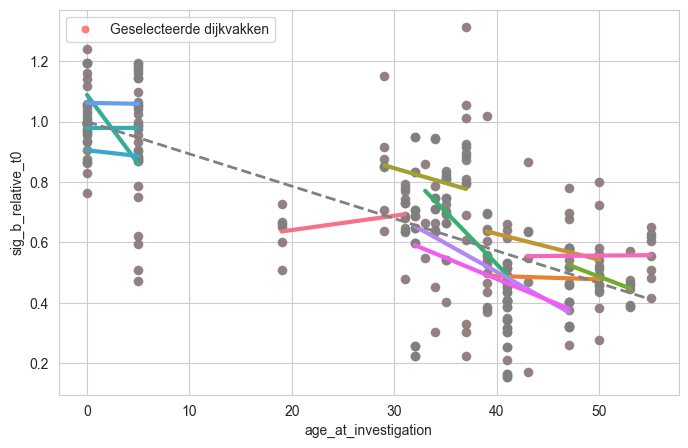

In [ ]:
#get intercept of regression based on all data
df_dikes_enriched['target'] = df_dikes_enriched['sig_b']
result = fit_linear_regression(df_dikes_enriched, use_HR_as_regressor=False)
intercept = result['beta'][0]
df_dikes_enriched['sig_b_relative_t0'] = df_dikes_enriched['sig_b'] / intercept
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b_relative_t0', color = 'red', alpha=0.5, ax=ax,label= 'Geselecteerde dijkvakken')
#for each main_dike_name, plot a line connecting the mean of the different investigation years
colors = sns.color_palette('husl', n_colors=len(df_dikes_enriched['main_dike_name'].unique()))
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b_relative_t0', ci=None, scatter=False, ax=ax, color=colors[i], label = main_dike, line_kws={'lw':3})
sns.regplot(data=df_dikes_enriched, x='age_at_investigation', y='sig_b_relative_t0', ci=None, scatter=True, color='gray', ax=ax, line_kws={'lw':2, 'ls':'--'})

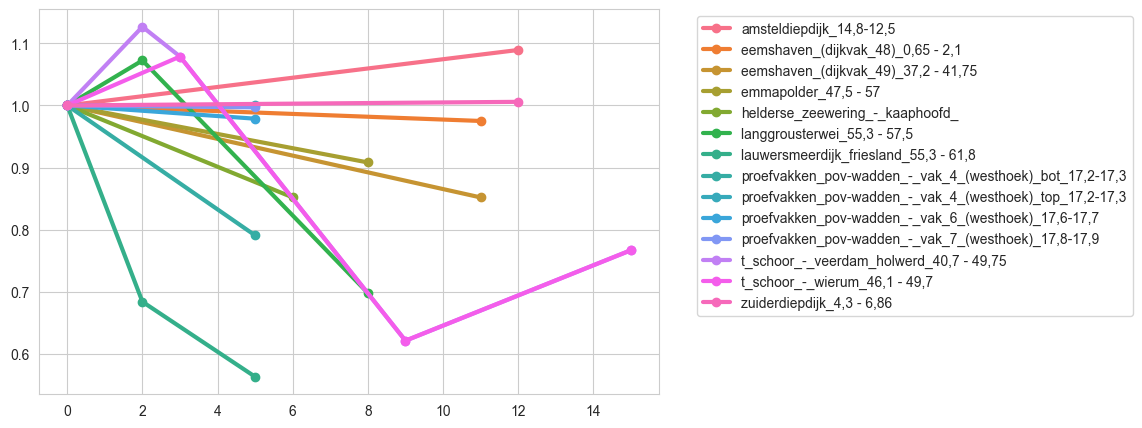

In [ ]:
#make a plot with for each main_dike_name the relative change in sig_b_mean over time 
fig, ax = plt.subplots(figsize=(8,5))
for i, main_dike in enumerate(df_dikes_enriched['main_dike_name'].unique()):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == main_dike]
    #compute initial mean
    initial_mean = dike_data.loc[dike_data['time_since_first_investigation'] == 0, 'sig_b'].mean()
    data_points = [(0, 1.0)] #(t, relative_value)
    #for each time_since_first_investigation that is non zero compute the relative value of the mean at that time
    unique_times = dike_data['time_since_first_investigation'].unique()
    for t in unique_times:
        if t != 0:
            mean_at_t = dike_data.loc[dike_data['time_since_first_investigation'] == t, 'sig_b'].mean()
            relative_value = mean_at_t / initial_mean
            data_points.append((t, relative_value))
    data_points = sorted(data_points, key=lambda x: x[0])
    data_points = np.array(data_points)
    ax.plot(data_points[:,0], data_points[:,1], marker='o', label=main_dike, color=colors[i], linewidth=3)
ax.legend(bbox_to_anchor = (1.05, 1), loc='upper left')

First the analysis proposed by Ruben

## Individual regression per section
As proposed by Ruben

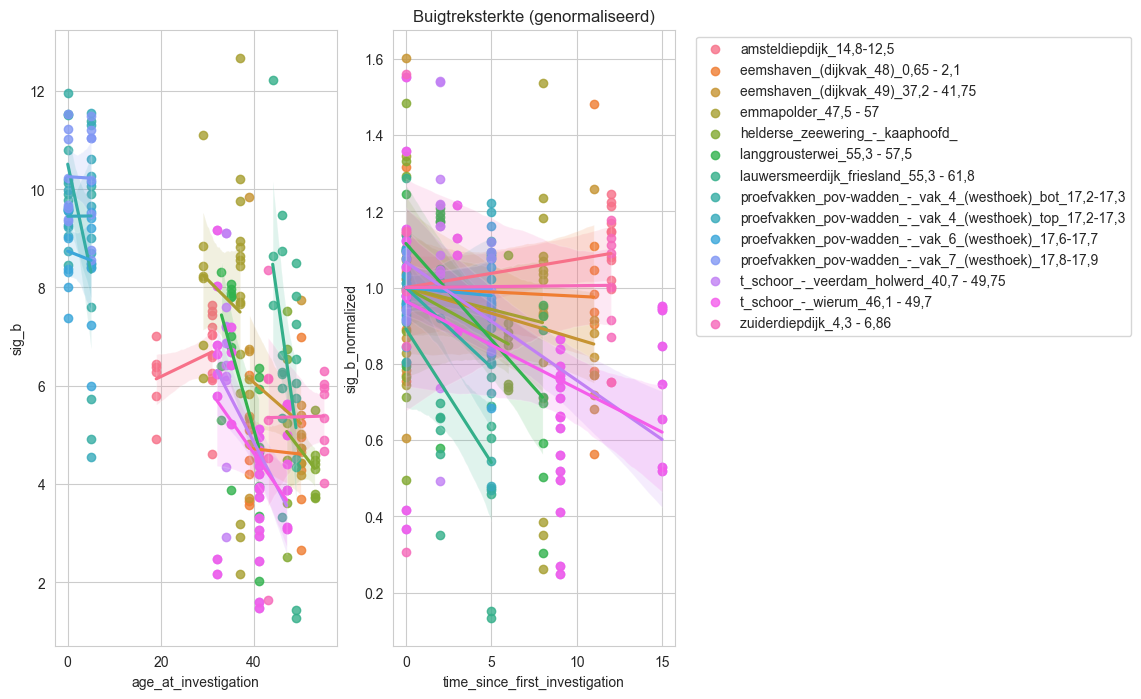

In [ ]:
import json
with open(working_dir.joinpath('heterogeneity_regression', 'log_y_False','lr_results_M1.json')) as f:
    lr_results = json.load(f)
    intercept = lr_results['Homogeen']['beta'][0]
    slope = lr_results['Homogeen']['beta'][1]
    std_intercept, std_slope = lr_results['Homogeen']['beta_ste']
    covariance_matrix = np.array(lr_results['Homogeen']['beta_cov'])
    standard_error = lr_results['Homogeen']['se']

regression_slope = {"Coef.": -0.08506413689801066,
                "Std.Err.": 0.004703399126419209}


# dike_datasets = []
fig, ax = plt.subplots(figsize=(8,8),ncols=2)
for count, dike in enumerate(main_dike_names):
    dike_data = df_dikes_enriched[df_dikes_enriched['main_dike_name'] == dike]
    sns.regplot(data=dike_data, x='age_at_investigation', y='sig_b', label=f"{dike}", ax=ax[0], color=colors[count])

    sns.regplot(data=dike_data, x='time_since_first_investigation', y='sig_b_normalized', label=f"{dike}", ax=ax[1],color=colors[count])
    ax[1].set_title('Buigtreksterkte (genormaliseerd)')

    # if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
    #     connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
    #     first_investigation_year = dike_data['investigation_year'].min()
    #     dike_data['year_since_first_investigation'] = dike_data['investigation_year'] - first_investigation_year

    #     if dike_data.number_of_boreholes.min()>=6:
    #         color = 'red'
    #     else:
    #         # continue
    #         color = 'blue'
    #     #ensure similarity between HR for different age_of_investigation
    #     HR_values = dike_data.groupby('year_since_first_investigation')['HR'].transform('mean')
    #     if HR_values.max() - HR_values.min() > 2:
    #         color = 'gray'
    #     #left we plot all sections where the HR mean for both cases is less than 6%
    #     # if (dike_data['HR'].mean() < 4):
    #     #     ax[0].set_title('Dijken met gemiddelde HR < 4%')
    #     #     ax[1].set_title('Dijken met gemiddelde HR ≥ 4%')
    #     # if all(dike_data['heterogeneity_category']!='Homogeen'):
    #     #     ax[0].set_title('Dijken met heterogene opbouw')
    #     #     ax[1].set_title('Dijken met homogene opbouw tijdens alle metingen')

        
    #     if all(dike_data.construction_year < 1980):
    #         ax[0].set_title('Dijken aangelegd voor 1980')
    #         ax[1].set_title('Dijken aangelegd na 1980')
            
    #         # sns.regplot(data=dike_data, x='year_since_first_investigation', y='sig_b', label=f"{dike}", ax=ax[0],color=color)
    #         # sns.regplot(data=dike_data, x='year_since_first_investigation', y='normalized_HR', label=f"{dike}", ax=ax[1],color=color)
    #     else:
    #         sns.regplot(data=dike_data, x='year_since_first_investigation', y='normalized_sig_b', label=f"{dike}", ax=ax[1],color=color)
    #     #for 0 to 14 plot the slope of the regression line using the regression_slope with uncertainty



# x_vals = np.array(range(0,15))
# #relative
# slope_to_use = slope/intercept
# intercept_to_use = 1
# #non-relative
# # slope_to_use = slope
# # intercept_to_use = intercept

# y_vals = intercept_to_use + slope_to_use * x_vals
# y_lower = intercept_to_use + (slope_to_use - 1.645*slope_to_use) * x_vals
# y_upper = intercept_to_use + (slope_to_use + 1.645*slope_to_use) * x_vals
# ax[0].plot(x_vals, y_vals, y_lower, y_upper, color='black',alpha=0.3)

# #generate legend for colors
# handles = [plt.Line2D([0], [0], marker='o', color='w', label='Min. 6 boringen', markerfacecolor='red', markersize=10),
#            plt.Line2D([0], [0], marker='o', color='w', label='Minder dan 6 boringen', markerfacecolor='blue', markersize=10),
#            plt.Line2D([0], [0], marker='o', color='w', label='Grote variatie ($\Delta \mu > 2 \%$ in HR)', markerfacecolor='gray', markersize=10),
#            plt.Line2D([0], [0], color='black', lw=2, label='Regressieanalyse (relatief)')]
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         #plot the slope of the actual regression line
#         # fit_linear_regression(dike_data)
        

In [ ]:
df_means

,main_dike_name,age_at_investigation,sig_b,normalized_sig_b_means
0,"amsteldiepdijk_14,8-12,5",19,6.139972,1.000000
1,"amsteldiepdijk_14,8-12,5",31,6.688607,1.089355
2,"eemshaven_(dijkvak_48)_0,65 - 2,1",39,4.726093,1.000000
3,"eemshaven_(dijkvak_48)_0,65 - 2,1",50,4.608108,0.975035
4,"eemshaven_(dijkvak_49)_37,2 - 41,75",39,6.144627,1.000000
5,"eemshaven_(dijkvak_49)_37,2 - 41,75",50,5.234519,0.851885
6,"emmapolder_47,5 - 57",29,8.258318,1.000000
7,"emmapolder_47,5 - 57",37,7.500503,0.908236
8,helderse_zeewering_-_kaaphoofd_,47,5.067994,1.000000
9,helderse_zeewering_-_kaaphoofd_,53,4.317453,0.851906


In [ ]:
df_dikes_enriched

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,HR_category,brittleness,material_class,construction_year_category,heterogeneity_category,main_dike_name,target,age_since_first_investigation,time_since_first_investigation,sig_b_normalized
0,128,12,1990,2009,6,12,P_0901480,"amsteldiepdijk_4,6 - 14,8",HHNK,19,...,HR 4-9%,bros,gemiddeld,1973-2000,Homogeen,"amsteldiepdijk_14,8-12,5",6.437024,0,0,1.048380
1,129,12,1990,2009,6,12,P_0901480,"amsteldiepdijk_4,6 - 14,8",HHNK,19,...,HR 4-9%,overgang,gemiddeld,1973-2000,Homogeen,"amsteldiepdijk_14,8-12,5",6.386477,0,0,1.040147
2,130,12,1990,2009,6,12,P_0901480,"amsteldiepdijk_4,6 - 14,8",HHNK,19,...,HR 4-9%,bros,gemiddeld,1973-2000,Homogeen,"amsteldiepdijk_14,8-12,5",6.283891,0,0,1.023440
3,131,12,1990,2009,6,12,P_0901480,"amsteldiepdijk_4,6 - 14,8",HHNK,19,...,HR 4-9%,bros,gemiddeld,1973-2000,Homogeen,"amsteldiepdijk_14,8-12,5",4.911376,0,0,0.799902
4,132,12,1990,2009,6,12,P_0901480,"amsteldiepdijk_4,6 - 14,8",HHNK,19,...,HR <4%,bros,gemiddeld,1973-2000,Homogeen,"amsteldiepdijk_14,8-12,5",7.021886,0,0,1.143635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,537,71,1966,2021,27,67,P_2004437,"zuiderdiepdijk_4,3-7,2",Waterschap Hollandse Delta,55,...,HR <4%,bros,gemiddeld,before 1973,Homogeen,"zuiderdiepdijk_4,3 - 6,86",5.830107,12,12,1.089711
601,538,71,1966,2021,27,67,P_2004437,"zuiderdiepdijk_4,3-7,2",Waterschap Hollandse Delta,55,...,HR 4-9%,overgang,gemiddeld,before 1973,Homogeen,"zuiderdiepdijk_4,3 - 6,86",5.352089,12,12,1.000364
602,539,71,1966,2021,27,67,P_2004437,"zuiderdiepdijk_4,3-7,2",Waterschap Hollandse Delta,55,...,HR >9%,bros,gemiddeld,before 1973,Homogeen,"zuiderdiepdijk_4,3 - 6,86",4.897755,12,12,0.915444
603,540,71,1966,2021,27,67,P_2004437,"zuiderdiepdijk_4,3-7,2",Waterschap Hollandse Delta,55,...,HR 4-9%,bros,gemiddeld,before 1973,Homogeen,"zuiderdiepdijk_4,3 - 6,86",6.044115,12,12,1.129712


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_12324\2603701374.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_means['normalized_sig_b_means'] = df_means.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['time_since_first_investigation'] == x['time_since_first_investigation'].min(), 'sig_b'].mean()).reset_index(level=0, drop=True)


(-1.0, 16.0)

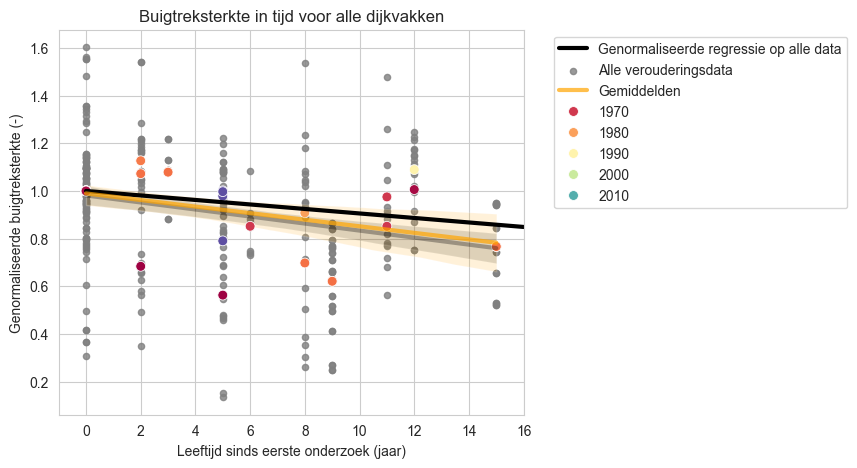

In [ ]:
fig,ax = plt.subplots(figsize=(6,5))
#for all data
# sns.regplot(data=df_dikes_enriched, x='time_since_first_investigation', y='sig_b_normalized', label = 'Alle data',ax=ax)
df_final_for_regression = df_final.loc[df_final.age_at_investigation <=50]
#drop nans for sig_b
df_final_for_regression = df_final_for_regression.dropna(subset=['sig_b'])
df_final_for_regression['target'] = df_final_for_regression['sig_b']
result_step_1 = fit_linear_regression(df_final_for_regression, use_HR_as_regressor=False)


df_final_for_regression['normalized_sig_b'] = df_final_for_regression['sig_b'] / result_step_1['beta'][0]

# df_final_for_regression['target'] = df_final_for_regression['normalized_sig_b']
# result = fit_linear_regression(df_final_for_regression, use_HR_as_regressor=False)

t_grid = np.linspace(0,16,25)
predicted_values = 1 + (result_step_1['beta'][1]/result_step_1['beta'][0] ) * t_grid
ax.plot(t_grid, predicted_values, color='black', lw=3, alpha=1, label='Genormaliseerde regressie op alle data')
sns.regplot(data= df_dikes_enriched, x='time_since_first_investigation', y='sig_b_normalized', color='gray', scatter=True, label='Alle verouderingsdata', line_kws={'lw':3,'color':'black','alpha':0.3}, scatter_kws={'s':20} , ax=ax)
#get means for each main_dike_name at each age_at_investigation
df_means = df_dikes_enriched.groupby(['main_dike_name', 'construction_year', 'time_since_first_investigation']).agg({'sig_b':'mean'}).reset_index()
#normalize these means
df_means['normalized_sig_b_means'] = df_means.groupby('main_dike_name').apply(lambda x: x['sig_b'] / x.loc[x['time_since_first_investigation'] == x['time_since_first_investigation'].min(), 'sig_b'].mean()).reset_index(level=0, drop=True) 

sns.regplot(data= df_means, x='time_since_first_investigation', y='normalized_sig_b_means', color='orange', scatter=False, label='Gemiddelden', line_kws={'lw':3,'color':'orange','alpha':0.7},ax=ax)
sns.scatterplot(data=df_means, x='time_since_first_investigation', y='normalized_sig_b_means', palette = 'Spectral', hue = 'construction_year', s = 50)
ax.set_xlabel('Leeftijd sinds eerste onderzoek (jaar)')
ax.set_ylabel('Genormaliseerde buigtreksterkte (-)')
plt.title('Buigtreksterkte in tijd voor alle dijkvakken')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(-1,16)


In [ ]:
dike_datasets_combined = pd.concat(dike_datasets, ignore_index=True)
dike_datasets_combined.main_dike_name.unique()
dike_datasets_combined.to_csv(results_dir.joinpath('data_voor_Ruben.csv'))

Punt 3: regressieanalyse

## Get individual regressions for each section.

In [ ]:
dike_list = dike_connections.index.tolist()
#also make a list of dike_names where there are multiple project_id's for the same dike_name
multiple_projects = dikes_and_projects.groupby('dike_name')['project_id'].nunique()
multiple_projects = multiple_projects[multiple_projects > 1].index.tolist()
results_dir.joinpath(f'timeseries_per_section_HR').mkdir(parents=True, exist_ok=True)
slope_intercept = {}
relative_reduction = []
full_dike_list = []
for count, dike in enumerate(dike_list):
    if (dike_connections.loc[dike, 'num_connections'] > 1) or (dike in multiple_projects):
        #filter the df_final for the dike and connected dikes
        connected_dikes = dike_connections.columns[dike_connections.loc[dike] == 1].tolist()
        dike_data = df_final[df_final['dike_name'].isin(connected_dikes + [dike])]
        dike_data["target"] = dike_data["sig_b"]
        #use relative dike_data for regression
        # dike_data["target"] = dike_data["sig_b"] / dike_data.loc[dike_data.age_at_investigation == dike_data.age_at_investigation.min(), 'sig_b'].mean()
        #do a regression with sklearn to get slope and intercept of sig_b vs age_at_investigation
        results = fit_linear_regression(dike_data, use_HR_as_regressor=False)
        slope_intercept[dike] = {'slope': results['summary_dict']['age_at_investigation']['Coef.'],
                                 'slope_std': results['summary_dict']['age_at_investigation']['Std.Err.'],
                                 'slope_ci_lo':  results['summary_dict']['age_at_investigation']['[0.025'], 
                                 'slope_ci_hi': results['summary_dict']['age_at_investigation']['0.975]'],
                                 'intercept': results['summary_dict']['const']['Coef.'],
                                 'intercept_ci_lo': results['summary_dict']['const']['[0.025'],
                                 'intercept_ci_hi': results['summary_dict']['const']['0.975]'],
                                 't0': dike_data['age_at_investigation'].min(),
                                 'tmax': dike_data['age_at_investigation'].max(),
                                 'min_number_of_boreholes': dike_data['number_of_boreholes'].min(),}
        first_year = dike_data['age_at_investigation'].min()
        last_year = dike_data['age_at_investigation'].max()
        relative_slope = (dike_data.loc[dike_data.age_at_investigation == last_year, 'sig_b'].mean()- dike_data.loc[dike_data.age_at_investigation == first_year, 'sig_b'].mean()) / (last_year - first_year)
        relative_reduction.append((first_year, relative_slope))
        full_dike_list.extend(connected_dikes + [dike])
#regressions for each
slope_intercept_df = pd.DataFrame.from_dict(slope_intercept, orient='index')
#drop nans
slope_intercept_df = slope_intercept_df.dropna()
slope_intercept_df = slope_intercept_df.drop_duplicates('intercept')

#full dike list only unique values
full_dike_list = list(set(full_dike_list))


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_12324\910751794.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data["target"] = dike_data["sig_b"]
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_12324\910751794.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dike_data["target"] = dike_data["sig_b"]
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_12324\910751794.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

In [ ]:
slope_intercept_df

,slope,slope_std,slope_ci_lo,slope_ci_hi,intercept,intercept_ci_lo,intercept_ci_hi,t0,tmax,min_number_of_boreholes
"amsteldiepdijk_14,8-12,5",0.045720,0.033540,-0.025383,0.116822,5.271300,3.309862,7.232739,19,31,6
"balgzanddijk_12,5-4,6",0.013261,0.063936,-0.126043,0.152566,6.135412,2.014043,10.256781,19,31,2
"eemshaven_(dijkvak_48)_0,65 - 2,1",-0.010726,0.049839,-0.117620,0.096168,5.144405,0.351437,9.937373,39,50,8
"eemshaven_(dijkvak_49)_37,2 - 41,75",-0.082737,0.068216,-0.229045,0.063571,9.371377,2.811130,15.931623,39,50,8
"emmapolder_47,5 - 57",-0.094727,0.142559,-0.391195,0.201742,11.005398,0.699951,21.310844,29,37,7
helderse_zeewering_-_kaaphoofd_,-0.125090,0.108932,-0.358726,0.108546,10.947234,-0.755583,22.650052,47,53,8
"langgrousterwei_55,3 - 57,5",-0.336216,0.103359,-0.554284,-0.118149,18.536608,10.390310,26.682906,33,41,3
"lauwersmeerdijk_friesland_55,3 - 61,8",-0.665805,0.265115,-1.220697,-0.110913,37.769073,11.588985,63.949162,44,49,3
"martina_corneliadijk_15,85 - 17,45",-0.007109,0.099240,-0.223335,0.209117,3.658092,-9.697015,17.013200,54,67,6
proefvakken_pov-wadden_-_vak_1_(harlingen)_-,-0.515095,0.224278,-0.996123,-0.034067,8.792094,7.091402,10.492786,0,5,8


In [ ]:
slope_intercept_df.loc[slope_intercept_df['min_number_of_boreholes']>=0, 'Bruikbaarheid'] = True
slope_intercept_df

#get for each section the significance of the slope defined as the p-value of slope being negative
slope_intercept_df['significant_decrease'] = slope_intercept_df['slope_ci_hi'] < 0
slope_intercept_df['significant_increase'] = slope_intercept_df['slope_ci_lo'] > 0

slope_intercept_df.loc[(slope_intercept_df['significant_decrease']) & (slope_intercept_df['Bruikbaarheid'])]
slope_intercept_df.loc[(slope_intercept_df['slope']<0) & (slope_intercept_df['Bruikbaarheid'])]

,slope,slope_std,slope_ci_lo,slope_ci_hi,intercept,intercept_ci_lo,intercept_ci_hi,t0,tmax,min_number_of_boreholes,Bruikbaarheid,significant_decrease,significant_increase
"eemshaven_(dijkvak_48)_0,65 - 2,1",-0.010726,0.049839,-0.117620,0.096168,5.144405,0.351437,9.937373,39,50,8,True,False,False
"eemshaven_(dijkvak_49)_37,2 - 41,75",-0.082737,0.068216,-0.229045,0.063571,9.371377,2.811130,15.931623,39,50,8,True,False,False
"emmapolder_47,5 - 57",-0.094727,0.142559,-0.391195,0.201742,11.005398,0.699951,21.310844,29,37,7,True,False,False
helderse_zeewering_-_kaaphoofd_,-0.125090,0.108932,-0.358726,0.108546,10.947234,-0.755583,22.650052,47,53,8,True,False,False
"langgrousterwei_55,3 - 57,5",-0.336216,0.103359,-0.554284,-0.118149,18.536608,10.390310,26.682906,33,41,3,True,True,False
"lauwersmeerdijk_friesland_55,3 - 61,8",-0.665805,0.265115,-1.220697,-0.110913,37.769073,11.588985,63.949162,44,49,3,True,True,False
"martina_corneliadijk_15,85 - 17,45",-0.007109,0.099240,-0.223335,0.209117,3.658092,-9.697015,17.013200,54,67,6,True,False,False
proefvakken_pov-wadden_-_vak_1_(harlingen)_-,-0.515095,0.224278,-0.996123,-0.034067,8.792094,7.091402,10.492786,0,5,8,True,True,False
"proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3",-0.439970,0.175891,-0.817217,-0.062722,10.510929,9.177158,11.844701,0,5,8,True,True,False
"proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5",-0.537667,0.116175,-0.788647,-0.286687,9.882180,9.024920,10.739440,0,5,7,True,True,False


In [ ]:
df_final.loc[df_final.age_at_investigation == 24]

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,E_ini,E_50,N_fat,number_of_boreholes,HR_category,brittleness,material_class,construction_year_category,heterogeneity_category,invloedrijk
720,721,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2552.0,2451.0,2000.0,8,HR <4%,ductiel,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
721,722,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,3225.0,3217.0,1200.0,8,HR <4%,overgang,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
722,723,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2575.0,2667.0,9000.0,8,HR 4-9%,bros,zwak,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
723,724,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,3212.0,2988.0,600.0,8,HR <4%,ductiel,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
724,725,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2170.0,2171.0,175.0,8,HR <4%,ductiel,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
725,726,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2089.0,2815.0,6000.0,8,HR <4%,bros,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
726,727,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2178.0,2836.0,18000.0,8,HR <4%,bros,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"
727,728,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,2086.0,2392.0,1000.0,8,HR <4%,ductiel,gemiddeld,1973-2000,Matig heterogeen,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7"


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

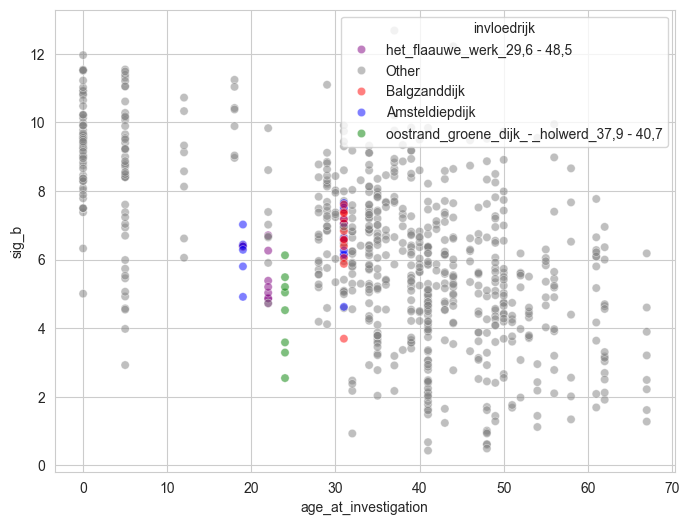

In [ ]:
#scatterplot with df_final where amsteldiepdijk and balgzanddijk are highlighted
fig, ax = plt.subplots(figsize=(8,6))
df_final.loc[df_final['dike_name'].str.contains('balgzanddijk'), 'invloedrijk'] = 'Balgzanddijk'
df_final.loc[df_final['dike_name'].str.contains('amsteldiepdijk'), 'invloedrijk'] = 'Amsteldiepdijk'
df_final.loc[df_final['dike_name'].str.contains('oostrand_groene_dijk_-_holwerd_37,9 - 40,7'), 'invloedrijk'] = 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7'
df_final.loc[df_final['dike_name'].str.contains('het_flaauwe_werk_29,6 - 48,5'), 'invloedrijk'] = 'het_flaauwe_werk_29,6 - 48,5'
#fill missing values with 'Other'
df_final['invloedrijk'] = df_final['invloedrijk'].fillna('Other')

sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='invloedrijk', palette={'Balgzanddijk': 'red', 'Amsteldiepdijk': 'blue', 'Other': 'gray', 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7': 'green', 'het_flaauwe_werk_29,6 - 48,5': 'purple'}, alpha=0.5, ax=ax)

<Axes: xlabel='relative_slope', ylabel='Count'>

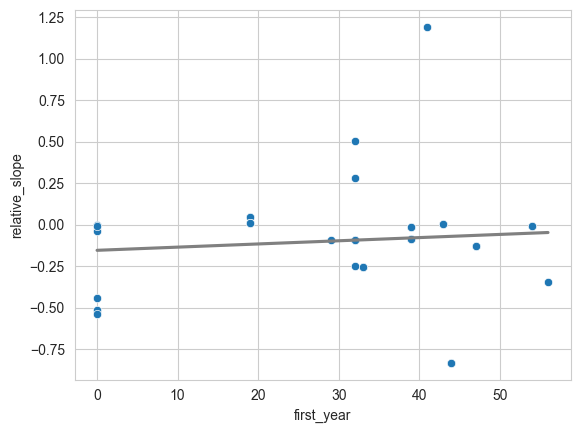

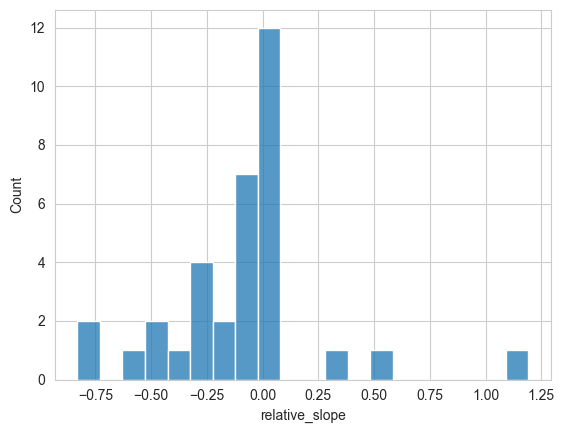

In [ ]:
sns.scatterplot(data=relative_reduction_df, x='first_year', y='relative_slope')
sns.regplot(data=relative_reduction_df, x='first_year', y='relative_slope', ci=None, scatter=False, color='gray')
plt.figure()
sns.histplot(relative_reduction_df['relative_slope'], bins=20)

In [ ]:
handels_selected[1]

Text(0, 0.5, 'Buigtreksterkte (MPa)')

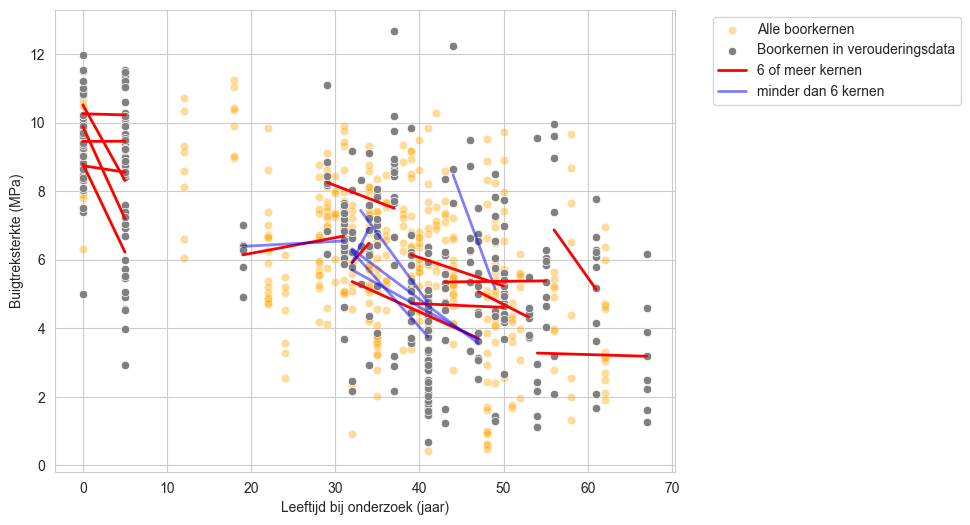

In [ ]:
#for each dike_name in slope_intercept_df, plot the regression line between t0 and tmax
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', ax=ax,alpha=0.4,color='orange') 
sns.scatterplot(data=df_final.loc[df_final.dike_name.isin(full_dike_list)], x='age_at_investigation', y='sig_b', ax=ax,color='gray') 
colors = sns.color_palette('Reds',n_colors=len(slope_intercept_df))
for dike_name, row in slope_intercept_df.iterrows():
    t0 = row['t0']
    tmax = row['tmax']
    slope = row['slope']
    intercept = row['intercept']
    x_vals = np.array([t0, tmax])
    y_vals = intercept + slope * x_vals
    # ax.plot(x_vals, y_vals, label=dike_name, linewidth=2, color=colors.pop(0))
    if row.min_number_of_boreholes >= 6:
        ax.plot(x_vals, y_vals, label=dike_name, linewidth=2, color='red')
    else:
        ax.plot(x_vals, y_vals, label=dike_name, linewidth=2, color='blue', alpha=0.5)

#make legend with scatter, blue and red line and 3 custom labels
ax.legend(labels=['Alle boorkernen', 'Boorkernen in verouderingsdata', '6 of meer kernen', 'minder dan 6 kernen'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')

Probability that slope < 0 for all sections: 0.7011


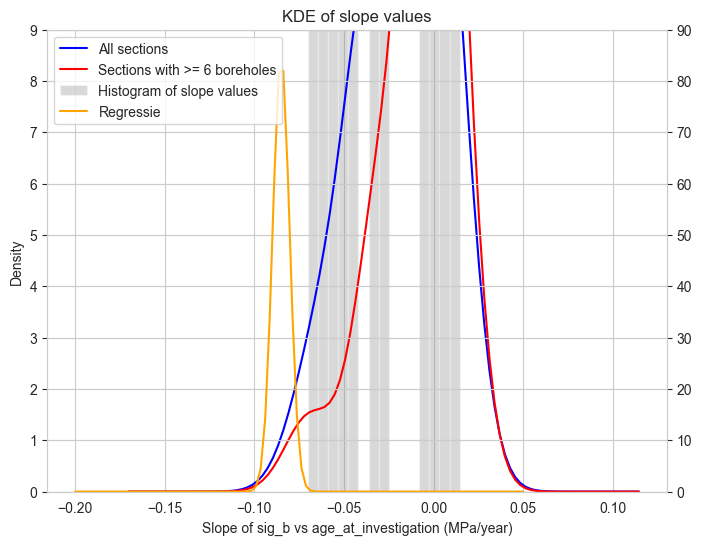

In [ ]:
#build kernel density estimate of slope values based on slope_intercept_df['slope'] and slope_intercept_df['slope_std']
from scipy.stats import gaussian_kde,norm

subset_zonder_pov = slope_intercept_df.loc[~slope_intercept_df.index.isin(['proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',])]

# subset_zonder_pov = slope_intercept_df.loc[~slope_intercept_df.index.isin(['proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
#  'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
#  'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
#  'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',
#  'proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6-17,7',
#  'proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8-17,9',])]
# # subset_zonder_pov = slope_intercept_df.copy()

x_grid = np.linspace(subset_zonder_pov['slope'].min()-0.1, subset_zonder_pov['slope'].max()+0.1, 100)

fig, ax = plt.subplots(figsize=(8,6))

#TODO: check weights
kde_1 = gaussian_kde(subset_zonder_pov['slope'], weights=1/subset_zonder_pov['slope_std'])
ax.plot(x_grid, kde_1(x_grid), label='All sections', color='blue')


kde_2 = gaussian_kde(subset_zonder_pov.loc[subset_zonder_pov.min_number_of_boreholes>=6, 'slope'], weights=1/subset_zonder_pov.loc[subset_zonder_pov.min_number_of_boreholes>=6, 'slope_std'])
ax.plot(x_grid, kde_2(x_grid), label='Sections with >= 6 boreholes', color='red')

#add histogram of slope values
ax.hist(subset_zonder_pov['slope'], bins=15, density=True, alpha=0.3, color='gray', label='Histogram of slope values')

ax.set_title('KDE of slope values')
ax.set_xlabel('Slope of sig_b vs age_at_investigation (MPa/year)')
ax.set_ylabel('Density')
ax.legend()
ax.set_ylim(0, 9)
#for kde_1 compute the probability that slope < 0
prob_slope_less_than_0_kde1 = kde_1.integrate_box_1d(-np.inf, 0)
print(f'Probability that slope < 0 for all sections: {prob_slope_less_than_0_kde1:.4f}')
full_population = {"Coef.": -0.08506413689801066,
                "Std.Err.": 0.004703399126419209}
# #add normal_distribution for full population
x_grid = np.linspace(-0.2, 0.05, 100)
# -0.09432166860681726, -0.07580660518920407
pdf_full = norm(loc=full_population["Coef."], scale=full_population["Std.Err."]).pdf(x_grid)
ax2 = ax.twinx()
ax2.plot(x_grid, pdf_full, label='Regressie',color='orange')
ax2.set_ylim(0, 90)
#get ax legend handles and labels
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2,  loc='upper left')
#remove ax legend
ax.legend().remove()
#

Text(0, 0.5, 'Buigtreksterkte (MPa)')

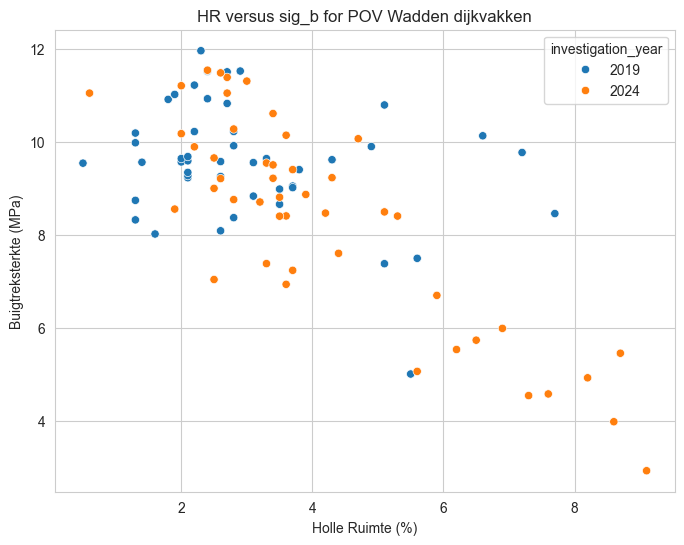

In [ ]:
subset_pov = slope_intercept_df.loc[slope_intercept_df.index.isin(['proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',
 'proefvakken_pov-wadden_-_vak_6_(westhoek)_17,6-17,7',
 'proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8-17,9',])]
fig, ax = plt.subplots(figsize=(8,6))
#plot HR versus sig_b voor alle kernen
sns.scatterplot(data=df_final[df_final['dike_name'].isin(subset_pov.index)], x='HR', y='sig_b', hue='investigation_year', palette='tab10', ax=ax)
ax.set_title('HR versus sig_b for POV Wadden dijkvakken')
ax.set_xlabel('Holle Ruimte (%)')
ax.set_ylabel('Buigtreksterkte (MPa)')

(0.0, 10.0)

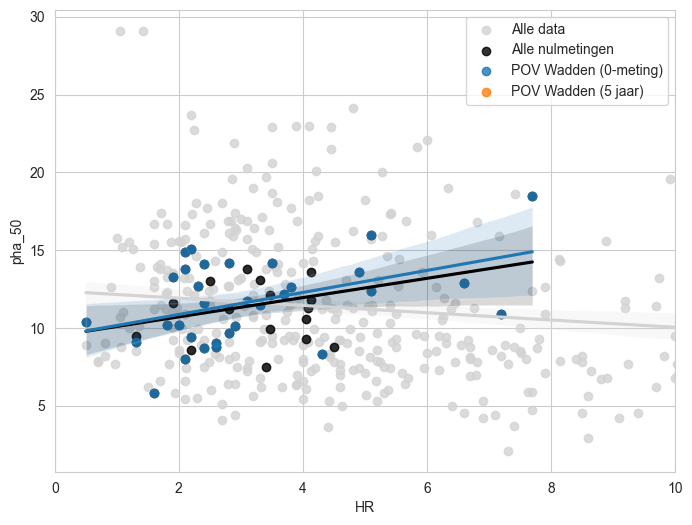

In [ ]:
#check V_ber for these sections
fig, ax = plt.subplots(figsize=(8,6))
# sns.scatterplot(data=df_final[df_final['dike_name'].isin(subset_pov.index)], x='V_Ber', y='sig_b', hue='investigation_year', palette='tab10', ax=ax)
y_par = 'pha_50'
sns.regplot(data=df_final, x='HR', y=y_par, scatter=True, ax=ax, color='lightgray',label='Alle data')
sns.regplot(data=df_final.loc[df_final.age_at_investigation == 0], x='HR', y=y_par, scatter=True, ax=ax, color='black', label='Alle nulmetingen')
sns.regplot(data=df_final.loc[(df_final['dike_name'].isin(subset_pov.index)) & (df_final.investigation_year == 2019)], x='HR', y=y_par, scatter=True, ax=ax, label='POV Wadden (0-meting)')
sns.regplot(data=df_final.loc[(df_final['dike_name'].isin(subset_pov.index)) & (df_final.investigation_year == 2024)], x='HR', y=y_par, scatter=True, ax=ax, label = 'POV Wadden (5 jaar)')
ax.legend()
ax.set_xlim(0, 10)

In [ ]:
df_final.loc[df_final.age_at_investigation == 22, ['dike_name', 'HR', 'sig_b', 'investigation_year']] 

,dike_name,HR,sig_b,investigation_year
0,"het_flaauwe_werk_29,6 - 48,5",3.708333,6.259762,2006
1,"het_flaauwe_werk_29,6 - 48,5",3.041667,5.381163,2006
2,"het_flaauwe_werk_29,6 - 48,5",5.208333,4.876932,2006
3,"het_flaauwe_werk_29,6 - 48,5",4.708333,6.708308,2006
4,"het_flaauwe_werk_29,6 - 48,5",4.708333,4.720396,2006
5,"het_flaauwe_werk_29,6 - 48,5",3.583333,4.855841,2006
6,"het_flaauwe_werk_29,6 - 48,5",3.000000,5.029682,2006
7,"het_flaauwe_werk_29,6 - 48,5",2.708333,5.201369,2006
116,"normerdijk_15,4 - 17,4",6.369692,7.017260,2009
117,"normerdijk_15,4 - 17,4",5.744782,6.646793,2009


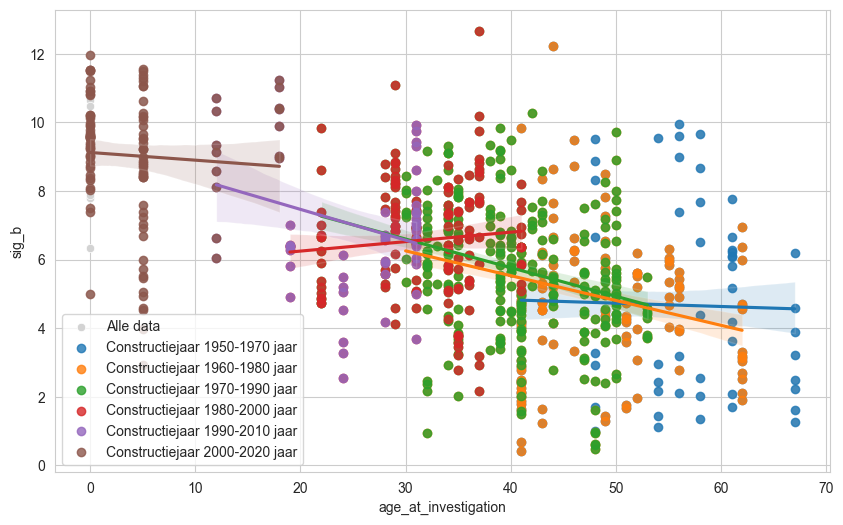

In [ ]:
#take df final and then run regressions for each period of 10 years by selecting only that part of the data
periods = [(0,15), (10,25), (20,35), (30,45), (40,55), (50,65), (60,75)]
constr_years = [(1950, 1960), (1960, 1970), (1970, 1980), (1980, 1990), (1990, 2000), (2000, 2010), (2010, 2020)]
#make constr_years such that periods are 20 years with 10 year overlap
constr_years = [(1950, 1970), (1960, 1980), (1970, 1990), (1980, 2000), (1990, 2010), (2000, 2020)]
#make the period 15 years, with 5 year overlap


fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', ax=ax, color='lightgray', label='Alle data')
# for start, end in periods:
for start, end in constr_years:
    period_data = df_final[(df_final['construction_year'] >= start) & (df_final['construction_year'] < end)]
    
    #only heterogeneity_category Homogeen
    # period_data = period_data[period_data['heterogeneity_category'] != 'Homogeen']
    #drop amsteldiepdijk and oostrand_groene_dijk_-_holwerd_37,9 - 40,7
    # period_data = period_data[~period_data['dike_name'].str.contains('balgzanddijk')]
    # period_data = period_data[~period_data['dike_name'].str.contains('amsteldiepdijk')]
    # period_data = period_data[~period_data['dike_name'].str.contains('oostrand_groene_dijk_-_holwerd_37,9 - 40,7')]
    # period_data = period_data[~period_data['dike_name'].str.contains('het_flaauwe_werk_29,6 - 48,5')]

    period_data = period_data[~period_data['dike_name'].isin(['amsteldiepdijk_14,8-12,5', 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7'])]
    sns.regplot(data=period_data, x='age_at_investigation', y='sig_b', scatter=True, ax=ax, label=f'Constructiejaar {start}-{end} jaar')

ax.legend()

<Axes: xlabel='age_at_investigation', ylabel='construction_year'>

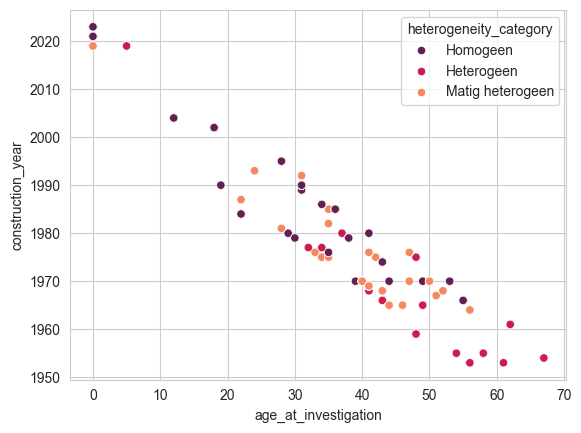

In [ ]:
sns.scatterplot(df_final, x='age_at_investigation', y='construction_year', hue = 'heterogeneity_category', palette='rocket')

In [ ]:
period_data

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,E_ini,E_50,N_fat,number_of_boreholes,HR_category,brittleness,material_class,construction_year_category,heterogeneity_category,invloedrijk
299,300,42,2004,2016,15,39,P_1600982,t_horntje_texel_-,HHNK,12,...,2756.0,2620.0,900.0,8,HR 4-9%,overgang,sterk,after 2000,Homogeen,Other
300,301,42,2004,2016,15,39,P_1600982,t_horntje_texel_-,HHNK,12,...,2729.0,2691.0,19500.0,8,HR 4-9%,overgang,sterk,after 2000,Homogeen,Other
301,302,42,2004,2016,15,39,P_1600982,t_horntje_texel_-,HHNK,12,...,2802.0,2670.0,15000.0,8,HR 4-9%,overgang,sterk,after 2000,Homogeen,Other
302,303,42,2004,2016,15,39,P_1600982,t_horntje_texel_-,HHNK,12,...,2665.0,2795.0,500.0,8,HR <4%,overgang,sterk,after 2000,Homogeen,Other
303,304,42,2004,2016,15,39,P_1600982,t_horntje_texel_-,HHNK,12,...,2373.0,2586.0,5000.0,8,HR 4-9%,overgang,gemiddeld,after 2000,Homogeen,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,708,92,2019,2024,35,50,P_2401206,"proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8...",Wetterskip Fryslân,5,...,NaN,NaN,NaN,8,HR <4%,ductiel,sterk,after 2000,Homogeen,Other
708,709,92,2019,2024,35,50,P_2401206,"proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8...",Wetterskip Fryslân,5,...,NaN,NaN,NaN,8,HR <4%,bros,sterk,after 2000,Homogeen,Other
709,710,87,2019,2024,35,45,P_2401206,proefvakken_pov-wadden_-_vak_1_(harlingen)_-,Wetterskip Fryslân,5,...,NaN,NaN,NaN,8,HR <4%,overgang,sterk,after 2000,Heterogeen,Other
710,711,87,2019,2024,35,45,P_2401206,proefvakken_pov-wadden_-_vak_1_(harlingen)_-,Wetterskip Fryslân,5,...,NaN,NaN,NaN,8,HR 4-9%,ductiel,sterk,after 2000,Heterogeen,Other


In [199]:
start_years = np.arange(1960, 2010, 1)
period = 15
outputs = []
#boxplots van sig_b met punten gekleurd als HR
excluded_sections = ['proefvakken_pov-wadden_-_vak_1_(harlingen)_-',
#  'proefvakken_pov-wadden_-_vak_4_(westhoek)_bot_17,2-17,3',
#  'proefvakken_pov-wadden_-_vak_4_(westhoek)_top_17,2-17,3',
 'proefvakken_pov-wadden_-_vak_5_(westhoek)_17,4-17,5',]
for start in start_years:
    end = start + period
    period_data = df_final[(df_final['construction_year'] >= start) & (df_final['construction_year'] <= end)].copy()
    period_data = period_data[~period_data['dike_name'].isin(excluded_sections)]
    #only Homogeen
    # period_data = period_data[period_data['heterogeneity_category'] == 'Homogeen']
    #drop amsteldiepdijk and oostrand_groene_dijk
    #drop 'oostrand_groene_dijk_-_holwerd_37,9 - 40,7 '
    # period_data = period_data[~period_data['dike_name'].isin(['beerkanaal_noordoostzijde_'])]
    # print(f'Constructiejaar {start}-{end} jaar: {len(period_data)} metingen')
    #copy sig_b to target
    # period_data["target"] = period_data["sig_b"]
    period_data['target'] = period_data['sig_b'].copy()
   
    #drop nans
    period_data = period_data.dropna(subset=['target', 'age_at_investigation'])
    if period_data.age_at_investigation.nunique() < 2:
        continue
    output = fit_linear_regression(period_data)
    if output['p_values'][1] < 0.05:
        print(f'{start}-{end}:  P-waarde = {output["p_values"][1]} (significant) op basis van {len(period_data)} metingen')
    else:
        print(f'{start}-{end}:  P-waarde = {output["p_values"][1]} (niet significant) op basis van {len(period_data)} metingen')
    outputs.append({'p-waarde': output['p_values'][1],
                    'start_year': start,
                    'end_year': end,
                    'num_measurements': len(period_data),
                    'num_of_projects': period_data.project_dike_id.nunique()})


1960-1975:  P-waarde = 0.0005379541534373933 (significant) op basis van 219 metingen
1961-1976:  P-waarde = 0.00013830533267713887 (significant) op basis van 267 metingen
1962-1977:  P-waarde = 9.688532834501706e-05 (significant) op basis van 303 metingen
1963-1978:  P-waarde = 9.688532834501706e-05 (significant) op basis van 303 metingen
1964-1979:  P-waarde = 1.281586952903222e-06 (significant) op basis van 319 metingen
1965-1980:  P-waarde = 5.203903026645059e-10 (significant) op basis van 370 metingen
1966-1981:  P-waarde = 4.0366365653093334e-13 (significant) op basis van 350 metingen
1967-1982:  P-waarde = 9.401572117236642e-12 (significant) op basis van 352 metingen
1968-1983:  P-waarde = 9.401572117236642e-12 (significant) op basis van 352 metingen
1969-1984:  P-waarde = 1.2670872246999417e-08 (significant) op basis van 333 metingen
1970-1985:  P-waarde = 2.571638561995393e-09 (significant) op basis van 345 metingen
1971-1986:  P-waarde = 1.1579519219897482e-06 (significant) op

Text(0.5, 0.98, 'P-waarde van regressie sig_b vs leeftijd bij onderzoek per constructieperiode (duur = 15 jaar, alleen homogene vakken)')

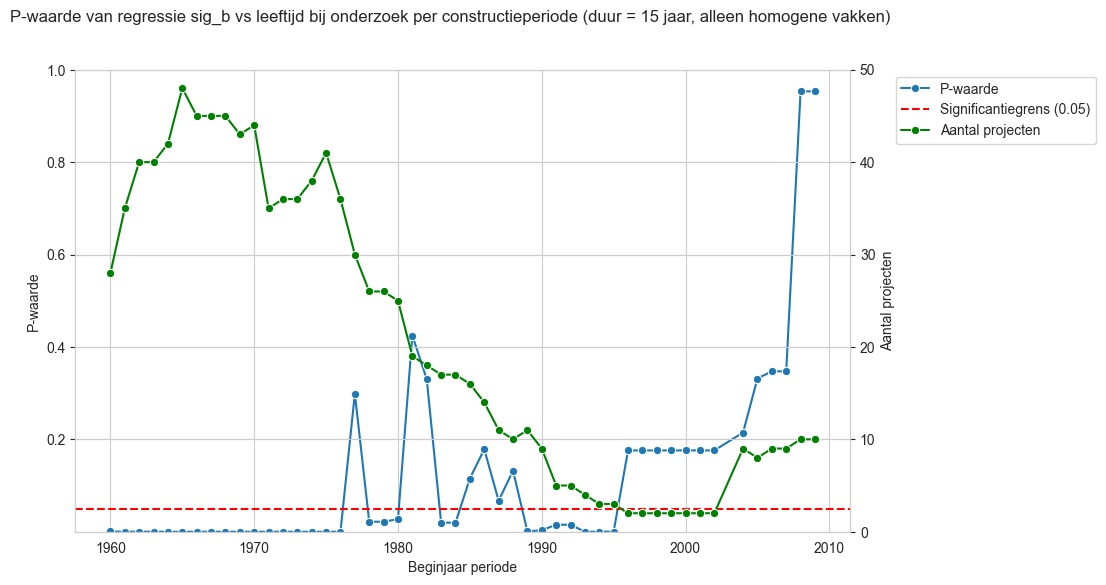

In [200]:
# get p-waarde and num_measurements from outputs and plot them
outputs_df = pd.DataFrame(outputs)
fig, ax1 = plt.subplots(figsize=(10,6))
sns.lineplot(data=outputs_df, x='start_year', y='p-waarde', marker='o', ax=ax1, label='P-waarde')
ax1.axhline(y=0.05, color='r', linestyle='--', label='Significantiegrens (0.05)')
ax1.set_ylabel('P-waarde')
ax2 = ax1.twinx()
# sns.lineplot(data=outputs_df, x='start_year', y='num_measurements', marker='o', color='orange', ax=ax2, label='Aantal boorkernen')
sns.lineplot(data=outputs_df, x='start_year', y='num_of_projects', marker='o', color='green', ax=ax2, label='Aantal projecten')
ax2.set_ylabel('Aantal projecten')
ax1.set_ylim(1e-5, 1)
ax2.set_ylim(0, 50)

#combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.05, 1))
ax2.legend().remove()
ax1.set_xlabel('Beginjaar periode')
# ax1.set_yscale('log')
fig.suptitle(f'P-waarde van regressie sig_b vs leeftijd bij onderzoek per constructieperiode (duur = {period} jaar, alleen homogene vakken)')


In [201]:
data_per_dike_section

NameError: name 'data_per_dike_section' is not defined

In [ ]:
#conceptually. If you have 2 normal distributions: one at t=0 with mean mu_0 and std sig_0, and one at t=10 with mean mu_1 and std sig_1, where mu_1  = mu_0 - 0.7 with mu_0 = 8, and sig remains constant at 1.6. Simulate a regression resulting from 8 samples from each distribution
np.random.seed(41)
n_samples = 32dd
mu_0 = 8
sig_0 = 1.4
mu_1 = mu_0 - 0.7
sig_1 = sig_0
t_0 = 0
t_1 = 10
samples_t0 = np.random.normal(mu_0, sig_0, n_samples)
samples_t1 = np.random.normal(mu_1, sig_1, n_samples)
ages = np.array([t_0]*n_samples + [t_1]*n_samples)
#make a dataframe and then do a seaborn linear regression plot
fake_data = pd.DataFrame({'age_at_investigation': ages,
                          'sig_b': np.concatenate([samples_t0, samples_t1])})
fig, ax = plt.subplots(figsize=(8,4), ncols=2)
sns.regplot(data=fake_data, x='age_at_investigation', y='sig_b', ax=ax[0], color='red', label='Illustratief voorbeeld')
ax[0].plot([t_0, t_1], [mu_0, mu_1], color='black', linestyle='--', label='Werkelijke afname van 0.7 MPa per 10 jaar')
#toon het gesamplede gemiddelde als punten
ax[0].plot([t_0, t_1], [samples_t0.mean(), samples_t1.mean()], marker='o', color='blue', linestyle='', label='Gemiddelde van gesamplede data')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
#put legend under plot
ax[0].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=1)

#do the same sampling 1000 times and then plot the distribution of slopes
samples_t0 = np.random.normal(mu_0, sig_0, (1000, n_samples))
samples_t1 = np.random.normal(mu_1, sig_1, (1000, n_samples))
slopes = []
for i in range(1000):
    fake_data = pd.DataFrame({'age_at_investigation': ages,
                              'sig_b': np.concatenate([samples_t0[i], samples_t1[i]]),
                              'heterogeneity_category': ["Homogeen"] * (2 * n_samples)})
    fake_data["target"] = fake_data["sig_b"]
    result = fit_linear_regression(fake_data, use_HR_as_regressor=False)
    slopes.append(result['beta'][1])

sns.histplot(slopes, bins=30, kde=True, ax=ax[1], color='red', label = 'Kansverdeling van $\Delta \sigma_b$/ jaar')
ax[1].axvline(x=-0.07, color='black', linestyle='--', label='Werkelijke afname van 0.7 MPa per 10 jaar')
ax[1].set_xlabel('Geschatte helling (MPa per jaar)')
ax[1].set_ylabel('Frequentie')
ax[1].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=1)
#bepaal de kans op overschatting met meer dan een factor 2 (dus slope < -0.14)
slopes = np.array(slopes)
prob_overshoot = np.sum(slopes < -0.14) / len(slopes)
print(f'Kans op overschatting van afname met meer dan factor 2: {prob_overshoot:.2%}')
prob_undershoot = np.sum(slopes > -0.035) / len(slopes)
print(f'Kans op onderschatting van afname met meer dan factor 2: {prob_undershoot:.2%}')
prob_groter_dan_nul = np.sum(slopes > 0) / len(slopes)
print(f'Kans op positieve helling: {prob_groter_dan_nul:.2%}')

